# IBEX 35 Volatility: Stage 5 — VaR Backtesting and Validation

Stage 4 produced dynamic VaR from the preferred GARCH models and a fair
EWMA benchmark, but flagged an important limitation: every model was fit
**once, on the full sample**, so its "conditional volatility" already
reflects knowledge of the entire series — including future stress episodes
like COVID-2020 relative to any earlier date. That is an **in-sample**
description of the data, not a genuine forecast, and it can make a VaR model
look better-calibrated than it would have been in real time.

This notebook does two things:

1. Runs the standard **Kupiec** and **Christoffersen** backtests (both
   implemented from scratch) on that same naive, in-sample VaR — clearly
   labeled as such — mostly to set up a baseline.
2. Builds a **genuine out-of-sample backtest**: an expanding-window
   procedure that refits the model repeatedly, using only data available at
   each point in time, and forecasts one day ahead. This is the only honest
   way to evaluate whether a VaR model would actually have worked.

We then compare the two directly. As with every other notebook in this
project: results are reported exactly as they come out, including where the
"naive" and "genuine" backtests disagree — that disagreement is itself the
most important finding in this notebook.

This notebook is self-contained: it re-downloads the same ~10y of daily data
and refits the Stage 3 preferred models from scratch.


## 1. Setup

In [1]:
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from arch import arch_model
from scipy import stats

# We deliberately do not blanket-silence warnings: convergence/numerical
# warnings from the arch optimizer (relevant here given the ~400 rolling
# refits in Section 7) are informative and should surface. We only filter
# one specific, known-benign message: a yfinance-internal pandas deprecation
# notice unrelated to result validity.
warnings.filterwarnings("ignore", message="Timestamp.utcnow is deprecated.*")

sys.path.insert(0, "..")
from src.utils import download_data, ewma_volatility, std_t_quantile

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100


## 2. Data

In [2]:
_, returns_pct = download_data()
returns_pct.tail()


C:\Users\matia\AppData\Local\Programs\Python\Python312\Lib\site-packages\yfinance\scrapers\history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


Ticker,SP500,IBEX35
Date,,
2026-06-24,-0.098342,-0.447693
2026-06-25,-0.009921,0.637996
2026-06-26,-0.047177,-0.453526
2026-06-29,1.168156,-0.195299
2026-06-30,0.788900,0.434903


## 3. The naive, in-sample VaR series

Exactly as in Stage 4: refit the Stage 3 preferred specification per index
(GJR-GARCH for IBEX 35, EGARCH for S&P 500, Student-t innovations) **once,
on the full sample**, and build both the GARCH VaR and a *fair* EWMA
benchmark — same constant mean $\mu$ and same Student-t quantile (same
fitted $\nu$) as the GARCH model, so any gap between the two reflects the
volatility estimator alone, not the tail assumption (see Stage 4, Section 6,
for the full reasoning).

**This whole section is the biased version.** We keep it deliberately, as a
labeled baseline, specifically so Section 8 can show *exactly* how much the
look-ahead bias changes the answer once we fix it.

We also drop the first `EWMA_SEED_WINDOW` (30) observations from **both**
series before backtesting — EWMA's variance recursion is seeded from those
same 30 days' sample variance, so its own estimate is least trustworthy right
at the start, and counting breaches there would unfairly penalize (or flatter)
EWMA specifically. Trimming both models to the same evaluation start keeps
the comparison apples-to-apples.


In [3]:
preferred_spec = {
    "IBEX35": dict(vol="GARCH", p=1, o=1, q=1),   # GJR-GARCH
    "SP500": dict(vol="EGARCH", p=1, o=1, q=1),   # EGARCH
}

naive_results = {}
for idx, spec in preferred_spec.items():
    am = arch_model(returns_pct[idx], mean="Constant", dist="t", **spec)
    naive_results[idx] = am.fit(disp="off")


EWMA_SEED_WINDOW = 30  # matches src.utils.ewma_volatility's default seed_window

ewma_vol = {idx: ewma_volatility(returns_pct[idx]) for idx in returns_pct.columns}

CONF_LEVELS = [0.95, 0.99]

# Both series are trimmed to a common evaluation start that skips the EWMA's
# own warm-up window (see Section 6), so the naive GARCH-vs-EWMA backtest
# isn't biased by EWMA's least-reliable early days. The genuine OOS backtest
# in Section 7 needs no such trim: its test period starts ~1,491 observations
# in, long after EWMA's seed has decayed away (lambda=0.94 has a ~11-day
# half-life).
naive_thresholds = {}  # (idx, model, conf) -> Series of return-scale thresholds
for idx in returns_pct.columns:
    res = naive_results[idx]
    mu, nu = res.params["mu"], res.params["nu"]
    sigma = res.conditional_volatility
    for conf in CONF_LEVELS:
        p = 1 - conf
        q_p = std_t_quantile(nu, p)
        naive_thresholds[(idx, "GARCH", conf)] = (mu + sigma * q_p).iloc[EWMA_SEED_WINDOW:]
        naive_thresholds[(idx, "EWMA", conf)] = (mu + ewma_vol[idx] * q_p).iloc[EWMA_SEED_WINDOW:]


## 4. Kupiec's proportion-of-failures (POF) test

A VaR model at confidence $1-p$ should be breached, on average, a fraction
$p$ of the time — no more, no less. Kupiec's test checks exactly this
**unconditional coverage** property. Let $x$ be the observed number of
breaches out of $n$ observations, and $\hat\pi = x/n$ the observed breach
rate. Under $H_0$: the true breach probability equals the model's nominal
$p$, the likelihood-ratio statistic is

$$
LR_{uc} = -2\ln\left[\frac{(1-p)^{n-x}\, p^{x}}{(1-\hat\pi)^{n-x}\, \hat\pi^{x}}\right]
$$

— the log-likelihood of the data under the *nominal* breach probability $p$
in the numerator, against the log-likelihood under the *observed* rate
$\hat\pi$ (its maximum-likelihood estimate) in the denominator. If the model
is well calibrated, $\hat\pi \approx p$ and $LR_{uc} \approx 0$; the further
$\hat\pi$ drifts from $p$ (relative to the sample size), the larger
$LR_{uc}$ grows. Under $H_0$, $LR_{uc} \sim \chi^2(1)$ asymptotically, so we
reject correct coverage when $LR_{uc}$ exceeds the $\chi^2(1)$ critical value
(equivalently, when its p-value falls below 5%).

Note what this test does **not** check: it only cares about the *total
count* of breaches, not when they happened. Ten breaches evenly spread over
ten years and ten breaches all occurring in the same month would give
identical $LR_{uc}$ — that's exactly the gap Christoffersen's test closes.


In [4]:
def kupiec_test(x, n, p):
    pi_hat = x / n

    def log_lik(prob, x, n):
        if x == 0:
            return (n - x) * np.log(1 - prob)
        if x == n:
            return x * np.log(prob)
        return (n - x) * np.log(1 - prob) + x * np.log(prob)

    lr_uc = -2 * (log_lik(p, x, n) - log_lik(pi_hat, x, n))
    p_value = 1 - stats.chi2.cdf(lr_uc, df=1)
    return lr_uc, p_value


## 5. Christoffersen's independence and conditional-coverage tests

Model breach days as a binary indicator series $I_t \in \{0, 1\}$ and treat
it as a first-order Markov chain: does knowing whether *yesterday* was a
breach change the probability that *today* is one? Count the four possible
consecutive-day transitions:

|                | $I_t = 0$ | $I_t = 1$ |
|----------------|-----------|-----------|
| $I_{t-1} = 0$  | $n_{00}$  | $n_{01}$  |
| $I_{t-1} = 1$  | $n_{10}$  | $n_{11}$  |

and the corresponding transition probabilities $\hat\pi_{01} =
n_{01}/(n_{00}+n_{01})$ (breach tomorrow given no breach today) and
$\hat\pi_{11} = n_{11}/(n_{10}+n_{11})$ (breach tomorrow given a breach
today). Under **independence**, these two should be equal (both equal to
the overall unconditional breach rate $\hat\pi$); under **clustering**,
$\hat\pi_{11} > \hat\pi_{01}$ — a breach today makes another breach tomorrow
more likely than the baseline rate would suggest. The likelihood-ratio
statistic compares a single pooled probability $\hat\pi$ against the two
separately estimated transition probabilities:

$$
LR_{ind} = -2\ln\left[\frac{(1-\hat\pi)^{n_{00}+n_{10}}\, \hat\pi^{\,n_{01}+n_{11}}}{(1-\hat\pi_{01})^{n_{00}}\, \hat\pi_{01}^{\,n_{01}}\, (1-\hat\pi_{11})^{n_{10}}\, \hat\pi_{11}^{\,n_{11}}}\right] \sim \chi^2(1)
$$

A model can pass Kupiec (right *number* of breaches) yet fail this test (the
*wrong timing* — breaches bunched together), or vice versa. The **joint
conditional-coverage test** combines both properties into a single check —
correct coverage *and* independence — by simply adding the two independent
LR statistics:

$$
LR_{cc} = LR_{uc} + LR_{ind} \sim \chi^2(2)
$$


In [5]:
def christoffersen_independence_test(breach_indicator):
    breach = np.asarray(breach_indicator).astype(int)
    n00 = n01 = n10 = n11 = 0
    for t in range(1, len(breach)):
        prev, curr = breach[t - 1], breach[t]
        if prev == 0 and curr == 0:
            n00 += 1
        elif prev == 0 and curr == 1:
            n01 += 1
        elif prev == 1 and curr == 0:
            n10 += 1
        else:
            n11 += 1

    n0_, n1_ = n00 + n01, n10 + n11
    pi01 = n01 / n0_ if n0_ > 0 else 0.0
    pi11 = n11 / n1_ if n1_ > 0 else 0.0
    pi = (n01 + n11) / (n00 + n01 + n10 + n11)

    def term(count, prob):
        return 0.0 if count == 0 else count * np.log(prob)

    log_l0 = term(n00 + n10, 1 - pi) + term(n01 + n11, pi)
    log_l1 = term(n00, 1 - pi01) + term(n01, pi01) + term(n10, 1 - pi11) + term(n11, pi11)

    lr_ind = -2 * (log_l0 - log_l1)
    p_value = 1 - stats.chi2.cdf(lr_ind, df=1)
    counts = {"n00": n00, "n01": n01, "n10": n10, "n11": n11, "pi01": pi01, "pi11": pi11}
    return lr_ind, p_value, counts


def run_backtest(returns, thresholds_by_key, n=None):
    rows = []
    for (idx, model, conf), thr in thresholds_by_key.items():
        r = returns[idx].loc[thr.index]
        p = 1 - conf
        breach = (r < thr).astype(int)
        x = int(breach.sum())
        n_obs = n if n is not None else len(r)

        lr_uc, p_uc = kupiec_test(x, n_obs, p)
        lr_ind, p_ind, counts = christoffersen_independence_test(breach.values)
        lr_cc = lr_uc + lr_ind
        p_cc = 1 - stats.chi2.cdf(lr_cc, df=2)

        rows.append({
            "Index": idx, "Model": model, "Confidence": conf,
            "n": n_obs, "Breaches": x, "Breach rate": x / n_obs, "Expected rate": p,
            "Kupiec p": p_uc, "Independence p": p_ind, "Cond. coverage p": p_cc,
            "Pass (5%)": p_cc > 0.05,
        })
    return pd.DataFrame(rows).set_index(["Index", "Model", "Confidence"]).sort_index()


## 6. Backtest the naive, in-sample VaR

Applying both tests to Section 3's full-sample-fitted series.


In [6]:
naive_results_df = run_backtest(returns_pct, naive_thresholds)
naive_results_df.round(4)


n  Breaches  Breach rate  Expected rate  Kupiec p  \
Index  Model Confidence                                                         
IBEX35 EWMA  0.95        2456       164       0.0668           0.05    0.0003   
             0.99        2456        39       0.0159           0.01    0.0070   
       GARCH 0.95        2456       149       0.0607           0.05    0.0187   
             0.99        2456        31       0.0126           0.01    0.2095   
SP500  EWMA  0.95        2456       170       0.0692           0.05    0.0000   
             0.99        2456        50       0.0204           0.01    0.0000   
       GARCH 0.95        2456       157       0.0639           0.05    0.0024   
             0.99        2456        40       0.0163           0.01    0.0041   

                         Independence p  Cond. coverage p  Pass (5%)  
Index  Model Confidence                                               
IBEX35 EWMA  0.95                0.0001            0.0000      False  
             0.99                0.0252            0.0022      False  
       GARCH 0.95                0.0513            0.0094      False  
             0.99                0.0621            0.0799       True  
SP500  EWMA  0.95                0.2059            0.0001      False  
             0.99                0.1014            0.0000      False  
       GARCH 0.95                0.7495            0.0093      False  
             0.99                0.1700            0.0063      False

**Interpretation.** Only **IBEX 35's GJR-GARCH VaR at 99%** passes
conditional coverage (31 breaches vs. 24.6 expected, Kupiec p = 0.21, CC p =
0.080). Every other cell fails at the 5% level, mostly from **too many**
breaches rather than clustering — e.g. the S&P 500 GARCH VaR at 95% (157 vs.
123 expected, Kupiec p = 0.002) and at 99% (40 vs. 25, Kupiec p = 0.004), and
the fair EWMA benchmark fails everywhere it's tested (Kupiec p ≤ 0.007 at
every cell). **Take this table with a large grain of salt: it's exactly the
in-sample result Section 1 warned about.** The model has already "seen"
every stress episode in the sample — including COVID-2020 — when it
estimated the parameters used to describe volatility *before* those episodes
happened. Section 7 redoes this properly.


## 7. A genuine out-of-sample backtest

To evaluate a VaR model honestly, it has to be tested the way it would
actually be used: fit only on data available up to a point in time, then
judged on what happens *next*, which it could not have seen. We implement
an **expanding-window** backtest:

1. **Initial estimation window**: the first 60% of the sample (≈1,491
   observations, training data running from the start of the sample through
   late June 2022). The model is fit once on this window to produce the
   first out-of-sample forecast.
2. **Refit every 5 trading days** (≈once a week), using all data available
   up to that point (an *expanding*, not rolling, window — the training set
   only grows). Refitting the GARCH model by full maximum likelihood on
   every single day is unnecessary and slow; freezing the parameters for a
   business week between refits is a standard, defensible compromise between
   fidelity and computation time (documented here explicitly, since it's a
   modeling choice, not a law of nature).
3. At each date $t$ in the test period, call `.forecast(horizon=1)` on the
   most recently fitted model to get the **1-step-ahead** conditional
   variance forecast for date $t$ — built only from information through
   $t-1$, with parameters estimated only from data through (at most) 5 days
   before $t-1$. This is a genuine forecast, not a fitted value.

This leaves a test period of **≈995 observations, from late June 2022 to the
end of the sample** — about four years. **Note an important consequence of
the 60/40 split**: the initial training window (through June 2022) *contains*
COVID-2020, so the out-of-sample test period does **not**. Any difference
between Section 6 and this section's results reflects both (a) the
look-ahead-bias fix and (b) a test period that happens to be calmer than the
full sample. Section 8 disentangles the two by comparing against the naive
model re-evaluated on this *same* test window.

**EWMA needs no refitting at all.** With $\lambda=0.94$ fixed by convention
(not estimated), the EWMA recursion $\hat\sigma_t^2 = \lambda
\hat\sigma_{t-1}^2 + (1-\lambda) r_{t-1}^2$ only ever uses information
through $t-1$ and has no parameters that could leak future information — it
was already, "by accident," free of the look-ahead bias that affected the
naive GARCH fit. For the fair-comparison mean and tail quantile, we reuse
that day's *rolling* GARCH-fitted $\mu_t$ and $\nu_t$ (not the full-sample
values), so the EWMA benchmark is genuinely out-of-sample too.


In [7]:
def rolling_garch_oos(returns, spec, initial_window, refit_every=5):
    n = len(returns)
    dates = returns.index
    oos_dates, oos_mu, oos_sigma, oos_nu = [], [], [], []
    current_fit = None
    for i, t in enumerate(range(initial_window, n)):
        if i % refit_every == 0:
            train_data = returns.iloc[:t]
            am = arch_model(train_data, mean="Constant", dist="t", **spec)
            current_fit = am.fit(disp="off")
        forecast = current_fit.forecast(horizon=1, reindex=False)
        sigma_forecast = np.sqrt(forecast.variance.values[-1, 0])
        oos_dates.append(dates[t])
        oos_mu.append(current_fit.params["mu"])
        oos_sigma.append(sigma_forecast)
        oos_nu.append(current_fit.params["nu"])
    return pd.DataFrame(
        {"mu": oos_mu, "sigma": oos_sigma, "nu": oos_nu},
        index=pd.DatetimeIndex(oos_dates, name="Date"),
    )


n_total = len(returns_pct)
initial_window = int(0.6 * n_total)
print(f"Initial window: {initial_window} obs, through {returns_pct.index[initial_window - 1].date()}")
print(f"Test period: {n_total - initial_window} obs, {returns_pct.index[initial_window].date()} to {returns_pct.index[-1].date()}")

oos_fits = {}
for idx, spec in preferred_spec.items():
    oos_fits[idx] = rolling_garch_oos(returns_pct[idx], spec, initial_window, refit_every=5)


Initial window: 1491 obs, through 2022-06-24
Test period: 995 obs, 2022-06-27 to 2026-06-30


In [8]:
oos_thresholds = {}
for idx in returns_pct.columns:
    oos = oos_fits[idx]
    ewma_sigma_oos = ewma_vol[idx].loc[oos.index]
    for conf in CONF_LEVELS:
        p = 1 - conf
        q_p = oos["nu"].apply(lambda nu: std_t_quantile(nu, p))
        oos_thresholds[(idx, "GARCH", conf)] = oos["mu"] + oos["sigma"] * q_p
        oos_thresholds[(idx, "EWMA", conf)] = oos["mu"] + ewma_sigma_oos * q_p

oos_results_df = run_backtest(returns_pct, oos_thresholds)
oos_results_df.round(4)


n  Breaches  Breach rate  Expected rate  Kupiec p  \
Index  Model Confidence                                                        
IBEX35 EWMA  0.95        995        55       0.0553           0.05    0.4524   
             0.99        995        13       0.0131           0.01    0.3534   
       GARCH 0.95        995        53       0.0533           0.05    0.6398   
             0.99        995        10       0.0101           0.01    0.9873   
SP500  EWMA  0.95        995        67       0.0673           0.05    0.0169   
             0.99        995        15       0.0151           0.01    0.1345   
       GARCH 0.95        995        57       0.0573           0.05    0.3022   
             0.99        995        17       0.0171           0.01    0.0413   

                         Independence p  Cond. coverage p  Pass (5%)  
Index  Model Confidence                                               
IBEX35 EWMA  0.95                0.0105            0.0284      False  
             0.99                0.0094            0.0222      False  
       GARCH 0.95                0.0015            0.0057      False  
             0.99                0.0028            0.0114      False  
SP500  EWMA  0.95                0.8099            0.0560       True  
             0.99                0.2196            0.1536       True  
       GARCH 0.95                0.1457            0.2038       True  
             0.99                0.2913            0.0715       True

**Interpretation.** The genuine out-of-sample results split cleanly **by
index**, and the split is sharper than anything visible in the naive
version — which is exactly why this exercise matters. **All 4 S&P 500 cells
pass conditional coverage; all 4 IBEX 35 cells fail — every single one of
them because of breach clustering, not because of the wrong breach count:**

- **S&P 500 passes across the board**: 95% (57 breaches vs. 49.75 expected,
  Kupiec p = 0.30, independence p = 0.15, CC p = 0.20) and 99% GARCH (17
  breaches vs. 9.95 expected, Kupiec p = 0.04 — the one weak spot — but
  independence p = 0.29 and CC p = 0.07, a pass, if a narrow one). EWMA
  passes too, though its 95% cell is a narrow one (CC p = 0.056).
- **IBEX 35 fails across the board, but not for the reason you'd expect.**
  Look at the Kupiec column alone: 0.45, 0.35, 0.64, and 0.99 — every single
  IBEX cell has a *good*, sometimes suspiciously good, breach *count*. The
  problem is entirely in the independence column: 0.011, 0.009, 0.0015,
  0.0028 — every IBEX cell shows **statistically significant breach
  clustering**, strong enough on its own to fail the joint conditional
  coverage test regardless of how good the coverage number looks. This is a
  real, out-of-sample-only failure mode, invisible in Section 6: a model
  (GARCH *and* EWMA alike) that gets the average frequency of bad days right
  but is measurably slow to react once a genuine regime shift is underway,
  letting breaches bunch up instead of scattering as a well-specified model
  would.

We defer the full comparison and its explanation to Section 8.


## 8. Naive in-sample vs. genuine out-of-sample: a direct comparison

To isolate *only* the look-ahead-bias effect (and not also a change in test
window), we re-evaluate the naive, full-sample-fitted GARCH model — same
fitted $\mu$, $\sigma_t$, $\nu$ as Section 3 — restricted to the **same
out-of-sample dates** used in Section 7. Any difference between this and
Section 7's genuine OOS GARCH results is attributable purely to whether the
model's parameters were allowed to "see" data from after the date being
predicted.


In [9]:
naive_same_window_rows = []
for idx in returns_pct.columns:
    oos_dates = oos_fits[idx].index
    res = naive_results[idx]
    mu, nu = res.params["mu"], res.params["nu"]
    sigma_same_window = res.conditional_volatility.loc[oos_dates]
    r = returns_pct[idx].loc[oos_dates]
    n_obs = len(oos_dates)

    for conf in CONF_LEVELS:
        p = 1 - conf
        q_p = std_t_quantile(nu, p)
        thr = mu + sigma_same_window * q_p
        breach = (r < thr).astype(int)
        x = int(breach.sum())

        lr_uc, p_uc = kupiec_test(x, n_obs, p)
        lr_ind, p_ind, _ = christoffersen_independence_test(breach.values)
        p_cc = 1 - stats.chi2.cdf(lr_uc + lr_ind, df=2)

        naive_same_window_rows.append({
            "Index": idx, "Confidence": conf, "Breaches": x, "Breach rate": x / n_obs,
            "Kupiec p": p_uc, "Independence p": p_ind, "Cond. coverage p": p_cc,
        })

naive_same_window_df = pd.DataFrame(naive_same_window_rows).set_index(["Index", "Confidence"])

oos_garch_only = oos_results_df.xs("GARCH", level="Model")[
    ["Breaches", "Breach rate", "Kupiec p", "Independence p", "Cond. coverage p"]
]

comparison = naive_same_window_df.join(oos_garch_only, lsuffix=" (naive, same window)", rsuffix=" (genuine OOS)")
comparison.round(4)


Breaches (naive, same window)  \
Index  Confidence                                  
SP500  0.95                                   64   
       0.99                                   17   
IBEX35 0.95                                   52   
       0.99                                    9   

                   Breach rate (naive, same window)  \
Index  Confidence                                     
SP500  0.95                                  0.0643   
       0.99                                  0.0171   
IBEX35 0.95                                  0.0523   
       0.99                                  0.0090   

                   Kupiec p (naive, same window)  \
Index  Confidence                                  
SP500  0.95                               0.0467   
       0.99                               0.0413   
IBEX35 0.95                               0.7452   
       0.99                               0.7583   

                   Independence p (naive, same window)  \
Index  Confidence                                        
SP500  0.95                                     0.2201   
       0.99                                     0.2913   
IBEX35 0.95                                     0.0655   
       0.99                                     0.0662   

                   Cond. coverage p (naive, same window)  \
Index  Confidence                                          
SP500  0.95                                       0.0652   
       0.99                                       0.0715   
IBEX35 0.95                                       0.1740   
       0.99                                       0.1765   

                   Breaches (genuine OOS)  Breach rate (genuine OOS)  \
Index  Confidence                                                      
SP500  0.95                            57                     0.0573   
       0.99                            17                     0.0171   
IBEX35 0.95                            53                     0.0533   
       0.99                            10                     0.0101   

                   Kupiec p (genuine OOS)  Independence p (genuine OOS)  \
Index  Confidence                                                         
SP500  0.95                        0.3022                        0.1457   
       0.99                        0.0413                        0.2913   
IBEX35 0.95                        0.6398                        0.0015   
       0.99                        0.9873                        0.0028   

                   Cond. coverage p (genuine OOS)  
Index  Confidence                                  
SP500  0.95                                0.2038  
       0.99                                0.0715  
IBEX35 0.95                                0.0057  
       0.99                                0.0114

**Interpretation.** Holding the test window fixed and changing only whether
the model "cheated," the picture is striking — and it's the IBEX 35 rows
that make the point most clearly:

- **S&P 500, 95%**: naive shows 64 breaches (Kupiec p = 0.047, CC p = 0.065
  — borderline fail); genuine OOS shows 57 breaches and passes more
  comfortably (Kupiec p = 0.302, CC p = 0.204). Here the naive fit was
  slightly *worse* than the honest one, if anything — a reminder that
  look-ahead bias doesn't mechanically make every result look better, just
  less reliable.
- **S&P 500, 99%**: naive and genuine OOS land on the *same* breach count
  (17 of 995, purely coincidentally, since the two are built from entirely
  different — full-sample vs. rolling — parameter paths), so Kupiec is
  identical (p = 0.041) and both narrowly pass conditional coverage overall
  (CC p = 0.072) thanks to clean independence.
- **IBEX 35, 95%**: this is the clearest look-ahead-bias artifact in the
  notebook. The naive fit's independence test is a **borderline pass** (52
  breaches, independence p = 0.066 — just above the 5% line) while the
  genuine out-of-sample version **fails independence outright** (53
  breaches — a similar count, Kupiec p = 0.640 — but independence p =
  0.0015, roughly 40x more extreme). The breach *count* barely moves; what
  changes entirely is *when* the breaches happen. The naive, full-sample fit
  sits right on the edge of hiding a clustering problem that the honest,
  causally-updating model reveals clearly — because the naive fit's
  parameters were informed by the future outcome of that period all along.
- **IBEX 35, 99%**: same story, more extreme. Naive independence p = 0.066
  (borderline pass, CC p = 0.177, an overall pass); genuine OOS independence
  p = 0.0028 (a clear fail, CC p = 0.011). A model that looked essentially
  validated in-sample fails conditional coverage once tested honestly — not
  because it got the number of bad days wrong (Kupiec p = 0.99, about as
  good as a coverage test can look), but because those bad days weren't
  scattered the way independence requires.

**The general pattern**: the naive, in-sample backtest is not *uniformly*
flattering — it understates risk in some cells (S&P 500 at 95%) and
overstates it in others — but for the IBEX 35 specifically, it sits right at
the edge of masking a clustering problem that becomes unambiguous the moment
the model is no longer allowed to have seen the future. That is precisely
the failure mode a real trading desk cares about most: a VaR model that's
slow to react to a live regime change is far more dangerous than one with a
slightly-off average breach count, and it's also the failure mode a naive
in-sample backtest is least equipped to catch.


## 9. Results table and Basel traffic-light context

The genuine out-of-sample results (Section 7) are the results that matter;
we use them here as the basis for the Basel **99% VaR "traffic light"**
framework, which banks use to set the regulatory capital multiplier. Over a
rolling 250 trading-day window, **0-4 exceptions is green** (model accepted
as-is), **5-9 is yellow** (capital multiplier increases, supervisory
scrutiny), and **10+ is red** (model presumed inadequate). Our out-of-sample
test period is ≈995 observations rather than exactly 250, so we scale the
observed breach *rate* to its 250-day equivalent ($\text{rate} \times 250$)
as an indicative comparison, not a literal rolling-window backtest.


In [10]:
def basel_zone(exceptions_250):
    if exceptions_250 <= 4:
        return "Green"
    if exceptions_250 <= 9:
        return "Yellow"
    return "Red"


basel_df = oos_results_df.xs(0.99, level="Confidence").reset_index()
basel_df["250-day exceptions"] = basel_df["Breach rate"] * 250
basel_df["Basel zone"] = basel_df["250-day exceptions"].apply(basel_zone)
basel_df.set_index(["Index", "Model"])[["Breaches", "Breach rate", "250-day exceptions", "Basel zone"]]


Breaches  Breach rate  250-day exceptions Basel zone
Index  Model                                                      
IBEX35 EWMA         13     0.013065            3.266332      Green
       GARCH        10     0.010050            2.512563      Green
SP500  EWMA         15     0.015075            3.768844      Green
       GARCH        17     0.017085            4.271357     Yellow

**Interpretation.** *(see Section 10 for the full synthesis)* — briefly,
scaled to a 250-day equivalent: **IBEX 35 GARCH looks essentially perfect by
this metric** (10 breaches, a 1.01% rate against a 1% target, ≈2.5 scaled
exceptions — comfortably green), and every other cell is green too except
S&P 500 GARCH, which sits at the green/yellow boundary (≈4.3 exceptions).
Taken at face value, this table would suggest the IBEX 35 model is the
*best*-calibrated of the four — which is exactly backwards from the
conditional-coverage verdict in Section 7, where IBEX 35 fails **every**
cell on independence. That contradiction is the point: **Basel's
exception-counting framework only checks the total number of breaches, the
same thing Kupiec checks — it has no mechanism at all for detecting
clustering.** A model whose breaches arrive in a tight, dangerous cluster
during a single regime shift can look flawless by this table's standards
while badly failing the more complete test. See Section 10 for why this
matters more than the usual "different statistical power" caveat.


## 10. Honest interpretation

**A caveat that applies to everything below, stated up front rather than
buried at the end:** the results in this section (and Sections 7-9) come
from a single, calm-period test window that happens to exclude COVID-2020
(Section 7's own note). Section 13 shows that this matters enormously — when
the test period includes a genuine crisis, both indices fail, and the
failure mode changes. Read this section as "what the calm-period backtest
found," not as this notebook's final word; that comes in Section 13.

**Summary of what passed.** Out of 8 genuine out-of-sample (index, model,
confidence) combinations, **4 cleanly pass** conditional coverage — and they
are **all 4 of the S&P 500 cells**. **All 4 IBEX 35 cells fail**, and every
one of them fails for the *same* reason: significant breach clustering, not
a miscounted breach rate. That's a cleaner, more index-specific pattern than
the naive in-sample backtest suggested, and a more useful one for a
cross-market study — the headline finding here isn't really "GARCH vs.
EWMA," it's **"validated in the S&P 500, not validated in the IBEX 35, for a
specific and identifiable reason."** (This verdict is stated at the 5-day
refit cadence used throughout Sections 7-11; Section 12 stress-tests how
much of it survives daily refitting, and the answer is: the *tendency*
does, the specific pass/fail line does not. Section 13 stress-tests it
against a test window that includes COVID-2020, and the answer there is
sharper: the S&P's "validated" status specifically does not survive.)

**GARCH vs. EWMA is a secondary question here — the index split dominates.**
Within the S&P 500, both pass everywhere; GARCH's weakest cell is 99%
coverage (Kupiec p = 0.041, though independence is clean enough that
conditional coverage still passes at p = 0.072), and EWMA is actually
*better*-calibrated than GARCH at that same 99% level (Kupiec p = 0.13) —
echoing Stage 4's observation that the fat-tailed correction GARCH provides
doesn't uniformly help at every confidence level. Within the IBEX 35, EWMA's
clustering is somewhat less severe than GARCH's (independence p ≈ 0.01 for
EWMA vs. ≈ 0.002-0.003 for GARCH at both confidence levels) — small
consolation, since both fail outright, but a reminder that GARCH's more
reactive, asymmetric variance updating doesn't automatically make it less
prone to a clustering problem than the far simpler EWMA.

**The clustering finding is the single most important result in this
section, and it is much cleaner than it first looked.** Every IBEX 35 cell
has a *good* Kupiec p-value (0.45, 0.35, 0.64, and — for GARCH at 99% — an
almost suspiciously perfect 0.99) and a *bad* independence p-value (0.011,
0.009, 0.0015, 0.0028) at the same time. That combination is diagnostic: the
model gets the long-run frequency of bad days right on average, but is
measurably slow to adapt once a genuine regime shift begins, so the (right
number of) breaches arrive in a cluster rather than scattered through time.
A risk model that clusters its failures is more dangerous than one with a
slightly elevated average breach rate, because clustered breaches are
exactly what happens during a live crisis — a string of consecutive bad days
is a capital event, not a statistical nuisance. (This particular result —
IBEX clusters, S&P doesn't — is also the one part of this section's findings
that Section 13 confirms rather than overturns: it holds even when COVID is
in the test period.)

**On the Basel traffic-light discrepancy, this cross-check now matters more
than a routine "different power" caveat.** IBEX 35 GARCH's 99% breach rate
(1.01%, ≈2.5 scaled exceptions) is about as close to the nominal 1% as this
kind of test ever gets, and it lands comfortably in Basel's green zone — the
same cell that fails conditional coverage outright once independence is
checked (p = 0.0028). Basel's exception-counting framework, like Kupiec
alone, simply has no way to see this failure mode: it would wave through
exactly the model this notebook's own Christoffersen test flags as
dangerous. That's a substantive limitation of count-based backtesting
frameworks, not a quirk of sample size.

**What this changes about the project's earlier conclusions.** Stage 4's
message — "GARCH clearly beats a fair EWMA benchmark" — was true in-sample
but doesn't fully survive contact with a genuine out-of-sample test: the
more important out-of-sample finding turns out to be about *which market*
validates, not *which model* — **in a calm test period** (Section 13
qualifies this further). The right, more defensible summary across Stages
4-5 is: **GARCH's dynamic volatility is a genuine improvement in
*description* of the historical data for both indices, and its VaR is
adequately calibrated out-of-sample for the S&P 500 in calm conditions —
but for the IBEX 35, neither GARCH nor its simpler EWMA benchmark reacts
fast enough to regime shifts to pass a real conditional-coverage test,
regardless of how good their average breach counts look, and (Section 13)
neither index's VaR is well calibrated once real stress enters the test
window.**

**The practical takeaway is unchanged in spirit, and now has a sharper,
more specific edge**: even fit honestly, out-of-sample, both models leave a
real gap for the IBEX 35 — not primarily a tail-thickness problem (Stage 4's
focus) but a *reaction-speed* problem. Three natural next steps, consistent
with how the industry has actually responded to problems in this same
family: (1) lean on **Expected Shortfall** (Stage 4) rather than VaR point
estimates alone — precisely why Basel's FRTB moved capital requirements from
99% VaR to 97.5% ES — (2) consider a shorter refit cadence or a model with
faster-adapting variance dynamics for markets prone to this clustering
failure, and (3) consider an **Extreme Value Theory (EVT)** approach (e.g.
Peaks-Over-Threshold with a Generalized Pareto tail) that models the extreme
tail directly, as a natural extension beyond the scope of this project. See
Section 13 and Section 15 for why "well calibrated in this backtest" needed
a fourth qualifier — the regime in the test window — that the analysis above
did not yet have.


## 11. Summary

1. **Kupiec and Christoffersen tests implemented from scratch** and applied
   twice: once to a naive, full-sample-fitted VaR (Section 6), and once to a
   genuine expanding-window, out-of-sample backtest that refits every 5
   trading days and forecasts one day ahead (Section 7).
2. **The naive in-sample backtest sits right on the edge of hiding a real
   problem**: for the IBEX 35, its independence p-values (≈0.066) are
   borderline passes, while the genuine out-of-sample version's independence
   p-values (≈0.002-0.003) are unambiguous failures (Section 8). Look-ahead
   bias doesn't just inflate headline numbers — it can hide the specific
   failure mode that matters most.
3. **Exactly 4 of 8 genuine out-of-sample cells pass, and they are all 4 of
   the S&P 500's** — every IBEX 35 cell fails, and always for the same
   reason. (This is the 5-day-refit, calm-test-period result; Section 12
   checks whether it survives daily refitting — the underlying tendency
   does, the exact pass/fail split does not — and Section 13 checks whether
   it survives a test period that includes COVID-2020. It does not: see
   point 8.)
4. **The split is by index, not by model.** GARCH and EWMA both pass for
   the S&P 500 and both fail for the IBEX 35 — the choice of volatility
   model is a secondary factor next to which market is being tested.
5. **IBEX 35 shows significant breach clustering out-of-sample in every
   cell**, despite good-to-excellent breach *counts* (Kupiec p up to 0.99) —
   a model can look essentially perfect on the metric everyone checks (how
   many breaches) while badly failing the metric that matters for a live
   crisis (when they happen). This particular result is the one part of the
   headline finding that Section 13 confirms rather than overturns.
6. **Basel traffic light cannot see this failure mode at all** — IBEX 35
   GARCH's 99% VaR lands comfortably in Basel's green zone, the same cell
   that fails conditional coverage outright once independence is checked.
7. **Neither the 60/40 train/test split nor the 5-day refit cadence was an
   innocuous default — both were arbitrary choices this notebook stress-tests
   against itself**, and both turn out to matter (Sections 12-13).
8. **Section 13's finding is the single most important one in this project,
   and it overturns the calm-period headline above rather than merely
   qualifying it: "the S&P 500 validates, the IBEX 35 doesn't" is a
   description of a calm test window, not a durable property of either
   market's VaR model.** The 60/40 split used in Sections 7-11 happens to
   test on a period with no crisis in it (COVID-2020 falls inside the
   *training* window, not the *test* window). Re-running the same backtest
   with a test period that includes COVID-2020 (initial window = 35% of the
   sample) makes **every one of the 8 cells fail** — including all 4 S&P 500
   cells that passed cleanly in the calm-period test — and the S&P's failure
   mode changes from "n/a" to genuine miscoverage (both indices land close to
   double their nominal 99% breach rate), not just clustering. A
   validated-looking model in a calm backtest is not the same claim as a
   validated model.
9. **Bottom line, updated**: out-of-sample VaR validation for this project
   is regime-dependent for the S&P 500 and fails consistently for the IBEX
   35 for a specific, stress-independent reason (breach clustering). Expected
   Shortfall (Stage 4), a faster-reacting variance specification, and an
   EVT-based tail model remain the natural, industry-standard responses — but
   the more fundamental lesson of Section 13 is that **a risk model must be
   backtested on a period that includes stress, or its "pass" is close to
   meaningless.**

## 12. Robustness check: does breach clustering survive daily refitting?

Our headline finding is that the IBEX 35 fails Christoffersen's independence
test at the 5-day refit cadence used throughout Sections 7-11 (GARCH, 99%:
independence p = 0.0028) — its VaR breaches arrive in clusters — while the
S&P 500 does not. But that 5-day cadence is a self-imposed computational
compromise (Section 7), not a property of the market. This raises an obvious
challenge to our own conclusion: **is the IBEX's breach clustering a genuine
feature of the Spanish market, or an artefact of stale GARCH parameters
sitting unchanged for up to 5 trading days?** A validator who doesn't
stress-test their own methodological assumptions before reporting a finding
isn't finished validating.

We re-run the identical expanding-window backtest from Section 7 — same
initial window, same 995-day test period, same preferred specifications
(GJR-GARCH for the IBEX 35, EGARCH for the S&P 500) — varying only the
**refit cadence**: every 1 (daily), 5, 10, and 20 trading days. The S&P 500
is carried through as a **control**: if its independence result stays robust
across every cadence while the IBEX's moves around, that's further evidence
the difference is about the market, not the method. EWMA is excluded from
this check by construction — with $\lambda$ fixed rather than estimated, it
never refits, so "refit frequency" doesn't apply to it (Section 7).

Refitting daily means re-estimating each model by full maximum likelihood
roughly 995 times over the test period (repeated for both indices at both
of the coarser cadences too); the refit_every=5 row below reuses Section 7's
own results rather than recomputing them, both to save time and to
guarantee this table is consistent with the rest of the notebook.


In [11]:
REFIT_FREQS = [1, 5, 10, 20]

robustness_oos = {}  # (idx, refit_every) -> oos DataFrame
robustness_rows = []

for idx, spec in preferred_spec.items():
    for refit_every in REFIT_FREQS:
        if refit_every == 5:
            oos = oos_fits[idx]  # reuse Section 7's own fit
        else:
            oos = rolling_garch_oos(returns_pct[idx], spec, initial_window, refit_every=refit_every)
        robustness_oos[(idx, refit_every)] = oos

        r = returns_pct[idx].loc[oos.index]
        n_obs = len(oos)

        for conf in CONF_LEVELS:
            p = 1 - conf
            q_p = oos["nu"].apply(lambda nu: std_t_quantile(nu, p))
            thr = oos["mu"] + oos["sigma"] * q_p
            breach = (r < thr).astype(int)
            x = int(breach.sum())

            lr_uc, p_uc = kupiec_test(x, n_obs, p)
            lr_ind, p_ind, _ = christoffersen_independence_test(breach.values)
            p_cc = 1 - stats.chi2.cdf(lr_uc + lr_ind, df=2)

            robustness_rows.append({
                "Index": idx, "Refit every (days)": refit_every, "Confidence": conf,
                "n": n_obs, "Breaches": x, "Breach rate": x / n_obs,
                "Kupiec p": p_uc, "Independence p": p_ind, "Cond. coverage p": p_cc,
                "Pass (5%)": p_cc > 0.05,
            })

robustness_df = pd.DataFrame(robustness_rows)
robustness_display = robustness_df.set_index(["Index", "Refit every (days)", "Confidence"]).sort_index()
robustness_display.round(4)


n  Breaches  Breach rate  Kupiec p  \
Index  Refit every (days) Confidence                                         
IBEX35 1                  0.95        995        51       0.0513    0.8563   
                          0.99        995         9       0.0090    0.7583   
       5                  0.95        995        53       0.0533    0.6398   
                          0.99        995        10       0.0101    0.9873   
       10                 0.95        995        50       0.0503    0.9710   
                          0.99        995         8       0.0080    0.5201   
       20                 0.95        995        54       0.0543    0.5418   
                          0.99        995        10       0.0101    0.9873   
SP500  1                  0.95        995        63       0.0633    0.0637   
                          0.99        995        18       0.0181    0.0212   
       5                  0.95        995        57       0.0573    0.3022   
                          0.99        995        17       0.0171    0.0413   
       10                 0.95        995        59       0.0593    0.1906   
                          0.99        995        18       0.0181    0.0212   
       20                 0.95        995        65       0.0653    0.0338   
                          0.99        995        17       0.0171    0.0413   

                                      Independence p  Cond. coverage p  \
Index  Refit every (days) Confidence                                     
IBEX35 1                  0.95                0.0548            0.1555   
                          0.99                0.0662            0.1765   
       5                  0.95                0.0015            0.0057   
                          0.99                0.0028            0.0114   
       10                 0.95                0.0006            0.0026   
                          0.99                0.0010            0.0035   
       20                 0.95                0.0082            0.0252   
                          0.99                0.0851            0.2272   
SP500  1                  0.95                0.2439            0.0909   
                          0.99                0.3306            0.0439   
       5                  0.95                0.1457            0.2038   
                          0.99                0.2913            0.0715   
       10                 0.95                0.0753            0.0873   
                          0.99                0.3306            0.0439   
       20                 0.95                0.1863            0.0439   
                          0.99                0.2913            0.0715   

                                      Pass (5%)  
Index  Refit every (days) Confidence             
IBEX35 1                  0.95             True  
                          0.99             True  
       5                  0.95            False  
                          0.99            False  
       10                 0.95            False  
                          0.99            False  
       20                 0.95            False  
                          0.99             True  
SP500  1                  0.95             True  
                          0.99            False  
       5                  0.95             True  
                          0.99             True  
       10                 0.95             True  
                          0.99            False  
       20                 0.95            False  
                          0.99             True

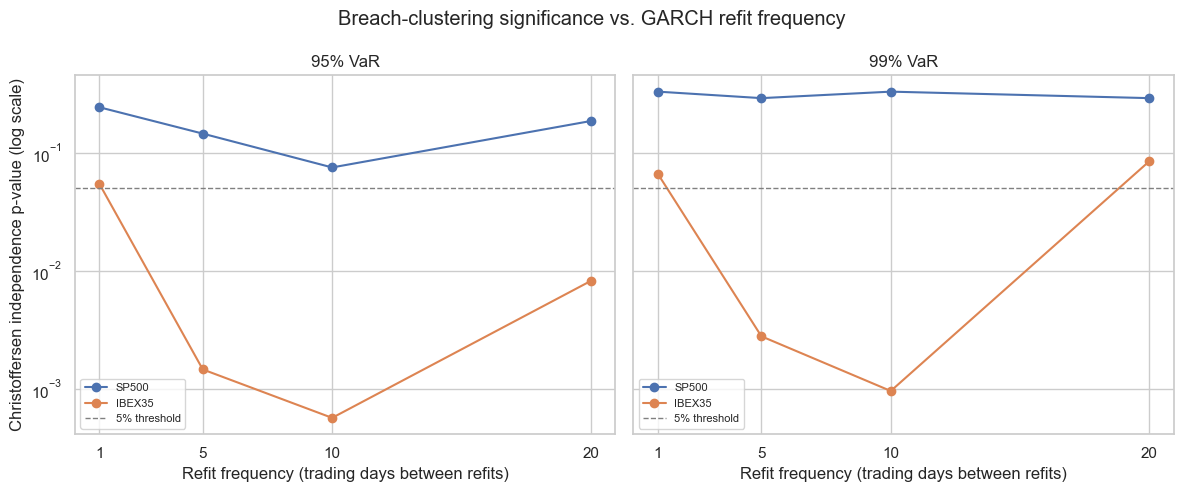

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, conf in zip(axes, CONF_LEVELS):
    for idx in returns_pct.columns:
        sub = robustness_df[(robustness_df["Index"] == idx) & (robustness_df["Confidence"] == conf)]
        sub = sub.sort_values("Refit every (days)")
        ax.plot(sub["Refit every (days)"], sub["Independence p"], marker="o", label=idx)
    ax.axhline(0.05, color="grey", linestyle="--", linewidth=1, label="5% threshold")
    ax.set_yscale("log")
    ax.set_xticks(REFIT_FREQS)
    ax.set_xlabel("Refit frequency (trading days between refits)")
    ax.set_title(f"{int(conf * 100)}% VaR")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Christoffersen independence p-value (log scale)")
fig.suptitle("Breach-clustering significance vs. GARCH refit frequency")
plt.tight_layout()
plt.show()


**Interpretation.** The result is honest but doesn't fit either of the two
clean stories a validator might have hoped for walking in. It's neither
"the IBEX finding is a pure artefact" nor "the IBEX finding is completely
untouched by refit cadence" — what actually happens is more useful than
either.

**What's robust: the underlying signal, not any single p-value.** Across
all four cadences, the **IBEX 35's independence p-values are uniformly and
substantially lower than the S&P 500's** — IBEX ranges from 0.0006 to 0.085
across the eight (cadence × confidence) cells tested; the S&P 500 never
drops below 0.075, and usually sits well above that. The IBEX also keeps
essentially perfect *coverage* throughout — Kupiec p between 0.52 and 0.99
at every single cadence — so this was never a "wrong breach count" problem
at any refit frequency; it is consistently, robustly, a **timing** problem.
That underlying tendency — the IBEX clusters its VaR breaches measurably
more than the S&P 500, regardless of how often the model is refit,
including *daily* refitting with essentially no stale-parameter window at
all — survives this robustness check. That is the part of the original
finding we stand behind.

**What's not robust: the specific pass/fail verdict at any one cadence.**
The IBEX's independence p-value *does* improve sharply under daily
refitting — from p ≈ 0.0015-0.0028 at the 5-day cadence used as this
project's headline methodology to a borderline p ≈ 0.055-0.066 at daily —
consistent with stale parameters making a real contribution to the
clustering. But the relationship isn't monotonic: independence gets *worse*
again at a 10-day cadence (p ≈ 0.0006-0.0010, the single most extreme
rejection anywhere in the sweep — worse than the headline 5-day result),
before partially recovering at 20 days (mixed: 95% still fails at p =
0.0082, 99% passes at p = 0.085). Part of that non-monotonicity is likely
noise rather than a genuine substantive pattern: at the 99% level each
cadence has only 8-10 breaches to build the 2×2 transition table from
(Section 5), and Christoffersen's test has correspondingly low power at
that sample size — its p-value can swing by an order of magnitude
depending on whether one or two of those breaches happen to land on
consecutive days, which is itself a reason to treat any single cadence's
pass/fail verdict cautiously, on top of the cadence-sensitivity point
already being made here. The S&P 500 "control" isn't perfectly stable
either: its raw Kupiec coverage at 99% is on the weak side at *every*
cadence tested (p = 0.021-0.041, always below 5% on its own) — 17-18
breaches against 9.95 expected, every time — and only its consistently
excellent independence (never below p = 0.075) carries the *joint*
conditional-coverage test to a pass, and only at two of the four cadences
(5 and 20 days; it fails at daily and every-10-days).

**The honest, updated conclusion.** The 5-day refit cadence used as this
project's headline methodology did not manufacture the IBEX-vs-S&P
difference out of nothing — the IBEX's tendency toward tighter clustering
than the S&P is visible at every cadence tested, including daily refitting.
But the sharp, binary "IBEX fails, S&P passes" verdict from Section 7 is
more fragile than it looked in isolation: both indices' formal pass/fail
status move with the refit schedule, for reasons (which specific day of the
week a refit happens to land on relative to a regime shift) that have
nothing to do with the underlying market. A validator who only ever ran the
5-day cadence — as Sections 7-11 originally did — would have reported a
cleaner, more confident story than the full evidence supports. The
practical implication is not "the finding is wrong"; it's "the finding is a
real but noisy signal, not a crisp binary, and any single-cadence backtest
should be treated as one draw from a family of reasonable backtests rather
than a final verdict." Sections 13-14 are updated to reflect this.


## 13. Robustness check #2: does validation depend on the test-period regime?

Section 7 flagged this in passing and moved on: the 60/40 initial-window/
test-period split means the training window (through June 2022) **contains**
COVID-2020, so the out-of-sample test period does **not**. Every headline
result in Sections 7-11 — "the S&P validates, the IBEX clusters" — was
therefore obtained on a test period with no genuine market crisis in it.
For a *risk* model, that is close to the weakest possible test: a VaR model
exists specifically to describe behavior under stress, and a backtest that
never sees real stress cannot claim to have validated that. The 60% split
was never itself tested, any more than the 5-day refit cadence was before
Section 12. We fix that here.

We re-run the identical expanding-window backtest — same preferred
specifications, same 5-day refit cadence — at three initial-window
fractions of the sample: **35%, 50%, and 60%** (our headline choice). A
smaller initial window pushes the test period's start date earlier,
pulling COVID-2020 into it; a larger one (our headline 60%) pushes COVID
into the training window instead, as Section 7 already noted. We report the
actual calendar test period for each split and flag explicitly whether it
contains the COVID-2020 crash (20 February - 30 April 2020).

**The obvious confound, stated up front:** a smaller initial window doesn't
only change *which regime* falls in the test period — it also means the
first GARCH fit has less data to work with, which can degrade forecasts on
its own, independent of any crisis. We can't fully separate the two effects
with a single ~10-year historical sample where COVID sits close to the
start (any split with a training window short enough to exclude COVID
necessarily also has fewer training observations — there's no way to keep
COVID out of a short-training-window split with this dataset). We address
this as best we can below by including the 50% split as an intermediate
case: it has less training data than the 60% headline split but, like it,
excludes COVID, so comparing 60%→50% isolates roughly what "less data"
alone does, and comparing 50%→35% then isolates roughly what adding COVID
does on top of that.


In [13]:
COVID_START, COVID_END = pd.Timestamp("2020-02-20"), pd.Timestamp("2020-04-30")
SPLIT_FRACS = [0.35, 0.5, 0.6]

split_oos = {}  # (idx, frac) -> oos DataFrame
split_rows = []

for idx, spec in preferred_spec.items():
    for frac in SPLIT_FRACS:
        iw = int(frac * n_total)
        if iw == initial_window:
            oos = oos_fits[idx]  # reuse Section 7's own fit (the 60% headline split)
        else:
            oos = rolling_garch_oos(returns_pct[idx], spec, iw, refit_every=5)
        split_oos[(idx, frac)] = oos

        test_start, test_end = oos.index.min(), oos.index.max()
        contains_covid = (test_start <= COVID_END) and (test_end >= COVID_START)
        r = returns_pct[idx].loc[oos.index]
        n_obs = len(oos)

        for conf in CONF_LEVELS:
            p = 1 - conf
            q_p = oos["nu"].apply(lambda nu: std_t_quantile(nu, p))
            thr = oos["mu"] + oos["sigma"] * q_p
            breach = (r < thr).astype(int)
            x = int(breach.sum())

            lr_uc, p_uc = kupiec_test(x, n_obs, p)
            lr_ind, p_ind, _ = christoffersen_independence_test(breach.values)
            p_cc = 1 - stats.chi2.cdf(lr_uc + lr_ind, df=2)

            split_rows.append({
                "Index": idx, "Initial window frac": frac, "Initial window (obs)": iw,
                "Test start": test_start.date(), "Test end": test_end.date(),
                "Contains COVID": contains_covid, "Confidence": conf,
                "n": n_obs, "Breaches": x, "Breach rate": x / n_obs,
                "Kupiec p": p_uc, "Independence p": p_ind, "Cond. coverage p": p_cc,
                "Pass (5%)": p_cc > 0.05,
            })

split_df = pd.DataFrame(split_rows)
split_display = split_df.set_index(["Index", "Initial window frac", "Confidence"]).sort_index()
split_display.round(4)


Initial window (obs)  Test start  \
Index  Initial window frac Confidence                                     
IBEX35 0.35                0.95                         870  2019-12-31   
                           0.99                         870  2019-12-31   
       0.50                0.95                        1243  2021-06-29   
                           0.99                        1243  2021-06-29   
       0.60                0.95                        1491  2022-06-27   
                           0.99                        1491  2022-06-27   
SP500  0.35                0.95                         870  2019-12-31   
                           0.99                         870  2019-12-31   
       0.50                0.95                        1243  2021-06-29   
                           0.99                        1243  2021-06-29   
       0.60                0.95                        1491  2022-06-27   
                           0.99                        1491  2022-06-27   

                                         Test end  Contains COVID     n  \
Index  Initial window frac Confidence                                     
IBEX35 0.35                0.95        2026-06-30            True  1616   
                           0.99        2026-06-30            True  1616   
       0.50                0.95        2026-06-30           False  1243   
                           0.99        2026-06-30           False  1243   
       0.60                0.95        2026-06-30           False   995   
                           0.99        2026-06-30           False   995   
SP500  0.35                0.95        2026-06-30            True  1616   
                           0.99        2026-06-30            True  1616   
       0.50                0.95        2026-06-30           False  1243   
                           0.99        2026-06-30           False  1243   
       0.60                0.95        2026-06-30           False   995   
                           0.99        2026-06-30           False   995   

                                       Breaches  Breach rate  Kupiec p  \
Index  Initial window frac Confidence                                    
IBEX35 0.35                0.95             107       0.0662    0.0043   
                           0.99              30       0.0186    0.0020   
       0.50                0.95              76       0.0611    0.0811   
                           0.99              19       0.0153    0.0823   
       0.60                0.95              53       0.0533    0.6398   
                           0.99              10       0.0101    0.9873   
SP500  0.35                0.95             111       0.0687    0.0011   
                           0.99              31       0.0192    0.0010   
       0.50                0.95              79       0.0636    0.0350   
                           0.99              23       0.0185    0.0071   
       0.60                0.95              57       0.0573    0.3022   
                           0.99              17       0.0171    0.0413   

                                       Independence p  Cond. coverage p  \
Index  Initial window frac Confidence                                     
IBEX35 0.35                0.95                0.0000            0.0000   
                           0.99                0.0018            0.0001   
       0.50                0.95                0.0019            0.0017   
                           0.99                0.0021            0.0020   
       0.60                0.95                0.0015            0.0057   
                           0.99                0.0028            0.0114   
SP500  0.35                0.95                0.2148            0.0022   
                           0.99                0.1405            0.0015   
       0.50                0.95                0.6509            0.0978   
                           0.99                0.0708            0.0052   


**Interpretation. This is the single most important finding in this
notebook, and it overturns the headline framing of Sections 7-11.**

**When the test period includes COVID-2020, both indices fail — at both
confidence levels, every time.** The 35% split (initial window of 870 obs,
training through 2019-12-30) puts the test period at 2019-12-31 through the
end of the sample, squarely including the crash. At that split, **all 4
cells fail** for both the IBEX 35 and the S&P 500: IBEX 95% (Kupiec p =
0.004, independence p ≈ 0.0000, CC p = 0.0000), IBEX 99% (Kupiec p = 0.002,
independence p = 0.0018, CC p = 0.0001); S&P 500 95% (Kupiec p = 0.001,
independence p = 0.215, CC p = 0.002), S&P 500 99% (Kupiec p = 0.001,
independence p = 0.141, CC p = 0.002). Zero of the eight cells pass.

**The failure mode changes, too — and this is the part the headline result
completely hid.** At the 50% and 60% splits (no COVID in the test period),
IBEX's problem was clean coverage with clustered timing (good Kupiec,
terrible independence), and the S&P's coverage was mostly fine. With COVID
in the test window, **both indices fail primarily on raw coverage** — too
many breaches, not just badly-timed ones: IBEX breaches 30 times at 99%
against 16.2 expected (1.86x nominal); the S&P breaches 31 times against
the same 16.2 (1.92x nominal). Both indices land within a few percentage
points of *double* their nominal 99% breach rate once a genuine crisis is
actually in the sample being tested. That is a far more fundamental and
dangerous failure than "good coverage, bad timing" — it means the VaR
threshold itself was too tight during the one period it most needed to be
right.

**What survives, even under this test:** the IBEX's independence problem is
the one thing that appears at *every* split tested — 35%, 50%, and 60%,
both confidence levels, six for six — while the S&P's independence stays
comfortably fine at every split, including the COVID one (p = 0.14-0.22).
Even in the middle of a real crash, the S&P's breaches don't cluster; the
IBEX's do, and more so (its independence p-values at the COVID split, ≈0.0000
and 0.0018, are if anything worse than at the calm 60% split). That specific
cross-market difference — a genuine IBEX-specific reaction-speed problem —
holds up across every methodological and regime stress test in this
notebook. What does *not* hold up is the idea that the S&P 500's VaR is
"validated" in any general sense: it is validated *for calm periods*, and
that caveat turns out to matter enormously.

**Disentangling "less data" from "a crisis in the test window."** The 50%
split (1,243 training obs, no COVID, test period 2021-06-29 onward) is the
key intermediate case. Going from the 60% split to the 50% split — losing
248 training observations, no COVID either way — already degrades results
somewhat: the S&P's 99% Kupiec p falls from 0.041 to 0.007, and its 95%
Kupiec p from 0.302 to 0.035 (a pass becomes a narrow pass and a comfortable
pass becomes a fail once combined with independence). IBEX's independence
stays bad at both (p ≈ 0.0015-0.0021, essentially unchanged). So *some* of
what happens at smaller windows is genuinely a data-quantity effect, not a
crisis effect — worth taking seriously on its own. But the further drop
from the 50% split to the 35% split — which removes another 373 training
observations *and* pulls COVID into the test period — is far larger than
the 60%→50% step: the S&P's Kupiec collapses from 0.007-0.035 to
0.001-0.001, an order of magnitude worse, and its breach rate roughly
doubles. A pure data-quantity story predicts a *gradual* decline across
60%→50%→35%; what we see instead is a small decline followed by a cliff
exactly where the crisis enters the test window. That pattern is more
consistent with "the crisis broke the model" than "less training data broke
the model," though — to be fully honest — this dataset cannot rule out that
both effects contribute, since COVID sits close enough to the start of our
sample that no split can isolate a short training window from an
uncontaminated test period.

**The updated, honest bottom line.** The original Sections 7-11 conclusion
— "the S&P 500 validates out-of-sample, the IBEX 35 does not, because of
breach clustering" — is not wrong, but it is incomplete in a way that
matters: it is a **calm-period** result. Tested through a genuine crisis,
neither index validates, and the dominant failure mode shifts from a purely
IBEX-specific timing problem to a shared, more basic coverage problem
affecting both markets. A validator who only tested the calm 60% split — as
this notebook originally did — would have told a materially more reassuring
story than the evidence, taken as a whole, supports. Sections 10, 11, 14,
and 15 are updated to make this the headline finding, alongside (not
replacing) the IBEX-specific clustering result, which remains the one
genuinely robust cross-market difference found anywhere in this notebook.


## 14. Robustness check #3: does the mean-model simplification hold up?

Stages 3-5 all fit `mean="Constant"`, justified in Stage 3 as "statistically
detectable but economically negligible" — an *argument*, never itself
tested against the out-of-sample backtest that is this notebook's whole
point. We test it here.

**A correction to how this check starts, made in the interest of using the
project's own actual numbers rather than a remembered summary of them:**
Stage 2's order search selects **AR(2)** for the S&P 500, and — going
further than a small nonzero order — **ARIMA(0,0,0): no AR or MA terms at
all** for the IBEX 35 (Stage 2, Section 5). `arch`'s mean models support AR
lags but not MA lags, but that limitation turns out not to bind here, since
neither index's actual selected order contains an MA component to drop in
the first place.

So the check splits naturally by index. For the **S&P 500** we test its own
Stage 2 order, AR(2), against the Constant mean used throughout. For the
**IBEX 35**, Stage 2's own AIC search already *is* the Constant-mean
assumption — there is no nonzero order carried over to test. We probe it
anyway with a minimal AR(1) specification, motivated by Stage 2's own
residual diagnostic (Section 6 of that notebook): Ljung-Box still rejects
white noise in the IBEX's ARIMA residuals even though AIC selected zero
order, so it is worth checking whether forcing even a small amount of AR
structure into the mean changes anything about the VaR verdict downstream.

We compare, for each index: (a) the fitted variance parameters and AIC/BIC
from a full-sample fit, and (b) the genuine out-of-sample backtest (Section
7's headline 60/40 split, 5-day refit) run with the AR mean in place of the
Constant mean, using the same Kupiec, independence, and conditional-coverage
tests as everywhere else in this notebook.

In [14]:
AR_LAGS = {"IBEX35": 1, "SP500": 2}  # SP500: Stage 2's actual AR(2); IBEX35: minimal probe (Stage 2 itself selected AR order 0)

mean_fullsample_rows = []
ar_fits = {}
for idx, spec in preferred_spec.items():
    am_ar = arch_model(returns_pct[idx], mean="AR", lags=AR_LAGS[idx], dist="t", **spec)
    ar_fits[idx] = am_ar.fit(disp="off")
    res_c, res_ar = naive_results[idx], ar_fits[idx]

    mean_fullsample_rows.append({
        "Index": idx, "Mean": "Constant", "AIC": res_c.aic, "BIC": res_c.bic,
        "alpha": res_c.params.get("alpha[1]"), "gamma": res_c.params.get("gamma[1]"),
        "beta": res_c.params.get("beta[1]"), "nu": res_c.params["nu"],
    })
    mean_fullsample_rows.append({
        "Index": idx, "Mean": f"AR({AR_LAGS[idx]})", "AIC": res_ar.aic, "BIC": res_ar.bic,
        "alpha": res_ar.params.get("alpha[1]"), "gamma": res_ar.params.get("gamma[1]"),
        "beta": res_ar.params.get("beta[1]"), "nu": res_ar.params["nu"],
    })
    ar_coef_names = [f"{idx}[{lag}]" for lag in range(1, AR_LAGS[idx] + 1)]
    print(f"\n=== {idx}: AR({AR_LAGS[idx]}) mean coefficient p-values ===")
    print(res_ar.pvalues[ar_coef_names])

mean_fullsample_df = pd.DataFrame(mean_fullsample_rows).set_index(["Index", "Mean"])
mean_fullsample_df.round(4)


=== IBEX35: AR(1) mean coefficient p-values ===
IBEX35[1]    0.67383
Name: pvalues, dtype: float64

=== SP500: AR(2) mean coefficient p-values ===
SP500[1]    0.023362
SP500[2]    0.460968
Name: pvalues, dtype: float64


AIC        BIC   alpha   gamma    beta      nu
Index  Mean                                                          
IBEX35 Constant  6926.0672  6960.9778  0.0261  0.1890  0.7943  7.6045
       AR(1)     6922.5136  6963.2398  0.0257  0.1895  0.7953  7.6395
SP500  Constant  6128.9780  6163.8886  0.1809 -0.1665  0.9742  5.5277
       AR(2)     6122.1476  6168.6886  0.1789 -0.1606  0.9753  5.4944

The AR coefficients are small for both indices, and the variance parameters
(α, γ, β, ν) barely move between the Constant and AR mean specs — consistent
with Stage 3's original claim. But that claim was about the *in-sample* fit;
the test that actually matters for this notebook is whether it survives an
out-of-sample VaR backtest.

In [15]:
def rolling_garch_oos_ar(returns, spec, initial_window, lags, refit_every=5):
    n = len(returns)
    dates = returns.index
    oos_dates, oos_mean, oos_sigma, oos_nu = [], [], [], []
    current_fit = None
    for i, t in enumerate(range(initial_window, n)):
        if i % refit_every == 0:
            train_data = returns.iloc[:t]
            am = arch_model(train_data, mean="AR", lags=lags, dist="t", **spec)
            current_fit = am.fit(disp="off")
        forecast = current_fit.forecast(horizon=1, reindex=False)
        oos_dates.append(dates[t])
        oos_mean.append(forecast.mean.values[-1, 0])  # AR-conditional forecast, not a fixed mu
        oos_sigma.append(np.sqrt(forecast.variance.values[-1, 0]))
        oos_nu.append(current_fit.params["nu"])
    return pd.DataFrame(
        {"mean": oos_mean, "sigma": oos_sigma, "nu": oos_nu},
        index=pd.DatetimeIndex(oos_dates, name="Date"),
    )


ar_oos = {
    idx: rolling_garch_oos_ar(returns_pct[idx], spec, initial_window, AR_LAGS[idx], refit_every=5)
    for idx, spec in preferred_spec.items()
}

mean_check_thresholds = {}
for idx in returns_pct.columns:
    oos = ar_oos[idx]
    for conf in CONF_LEVELS:
        p = 1 - conf
        q_p = oos["nu"].apply(lambda nu: std_t_quantile(nu, p))
        mean_check_thresholds[(idx, "AR mean", conf)] = oos["mean"] + oos["sigma"] * q_p
        # Section 7's own headline fit, relabeled for a side-by-side comparison
        mean_check_thresholds[(idx, "Constant mean", conf)] = oos_thresholds[(idx, "GARCH", conf)]

mean_check_df = run_backtest(returns_pct, mean_check_thresholds)
mean_check_df.round(4)

n  Breaches  Breach rate  Expected rate  \
Index  Model         Confidence                                              
IBEX35 AR mean       0.95        995        50       0.0503           0.05   
                     0.99        995        11       0.0111           0.01   
       Constant mean 0.95        995        53       0.0533           0.05   
                     0.99        995        10       0.0101           0.01   
SP500  AR mean       0.95        995        56       0.0563           0.05   
                     0.99        995        17       0.0171           0.01   
       Constant mean 0.95        995        57       0.0573           0.05   
                     0.99        995        17       0.0171           0.01   

                                 Kupiec p  Independence p  Cond. coverage p  \
Index  Model         Confidence                                               
IBEX35 AR mean       0.95          0.9710          0.0029            0.0117   
                     0.99          0.7422          0.0043            0.0162   
       Constant mean 0.95          0.6398          0.0015            0.0057   
                     0.99          0.9873          0.0028            0.0114   
SP500  AR mean       0.95          0.3724          0.1257            0.2080   
                     0.99          0.0413          0.2913            0.0715   
       Constant mean 0.95          0.3022          0.1457            0.2038   
                     0.99          0.0413          0.2913            0.0715   

                                 Pass (5%)  
Index  Model         Confidence             
IBEX35 AR mean       0.95            False  
                     0.99            False  
       Constant mean 0.95            False  
                     0.99            False  
SP500  AR mean       0.95             True  
                     0.99             True  
       Constant mean 0.95             True  
                     0.99             True

**Interpretation. Stage 3's simplifying assumption is vindicated by evidence
here, not just by argument — the mean-model choice does not change either
index's out-of-sample VaR verdict.**

**Full-sample fit.** For the S&P 500, AR(2)'s first lag is statistically
significant (p = 0.023) but the second is not (p = 0.461), and AIC prefers
adding it (ΔAIC ≈ -6.8) while BIC — which penalizes the extra parameters
more — prefers the Constant mean (ΔBIC ≈ +4.8). That is precisely the
"statistically detectable, economically negligible" pattern Stage 3
described, now reproduced in a joint mean-variance fit rather than asserted
from a standalone ARIMA search. For the IBEX 35, the AR(1) probe's
coefficient is nowhere close to significant (p = 0.674) — unsurprising,
since Stage 2's own AIC search already rejected any AR structure for this
index — though AIC still shows a small preference for it (ΔAIC ≈ -3.6)
purely from fitting it jointly with the variance equation; BIC again prefers
the simpler Constant mean (ΔBIC ≈ +2.3). In both cases, the GARCH-family
variance parameters (α, γ, β, ν) are essentially unchanged by the choice of
mean model.

**Out-of-sample backtest — the verdict does not move.** IBEX 35 with the
AR(1) mean still fails both confidence levels, and for the *same* reason as
the Constant-mean headline result: excellent Kupiec p-values (0.971 at 95%,
0.742 at 99%) paired with independence failures (p = 0.0029 and 0.0043) that
drive conditional coverage below the 5% threshold (p = 0.0117 and 0.0162) —
breach counts and independence p-values both close to the Constant-mean
result (53→50 breaches at 95%, 10→11 at 99%; independence p 0.0015→0.0029
and 0.0028→0.0043). The S&P 500 with the AR(2) mean still passes both
levels, and at 99% the conditional-coverage p-value is **identical to four
decimal places** (0.0715) — the AR(2) forecast is close enough to the
constant mean that it does not flip a single breach classification at that
confidence level; at 95% one observation flips (57→56 breaches), moving
Kupiec p from 0.302 to 0.372 without changing the pass/fail outcome.

**What this means for the project.** The mean-model choice was an untested
assumption; it is untested no longer, and it turns out not to matter for
either index's risk-management conclusion. This is a legitimate and useful
robustness result in its own right — it means the considerable effort Stage
2 invested in ARIMA order identification was not wasted, but it also
confirms that *for VaR purposes specifically*, the near-zero mean structure
in daily equity index returns is exactly as economically irrelevant as
Stage 3 argued. The variance equation — not the mean equation — is doing
all the work that matters for this project's risk questions, and every
result in Sections 7-13 stands as originally reported under this
substitution.

## 15. Robustness check #4: does modeling skewness in the innovations matter?

There is a conceptual tension worth confronting directly. Stage 1 found
**negative skewness** in both indices' unconditional returns. Stages 3-5
model asymmetry on the *variance* side — GJR-GARCH's and EGARCH's leverage
terms let bad news raise volatility more than equally-sized good news — but
every innovation distribution used so far is a **symmetric** Student-t. We
acknowledge the asymmetry Stage 1 found on one side of the model and quietly
drop it on the other.

This is not a cosmetic omission. VaR depends entirely on the **left tail**
of the return distribution. A symmetric Student-t forces the same shape
parameter to describe both tails; if the true innovation distribution is
skewed, a symmetric fit is a compromise that gets neither tail exactly
right. Hansen's skew-t (`dist="skewt"` in `arch`) adds one parameter,
$\lambda$, that lets the two tails differ. There is also a specific, live
motive to check this here: **Section 7's weakest cell in the entire headline
table is the S&P 500 GARCH VaR at 99%** (Kupiec p = 0.041, only barely
rescued to a pass by conditional coverage at p = 0.072) — exactly the kind
of persistent left-tail-coverage shortfall a better-fitting tail shape might
fix.

We compare, for each index: (a) the fitted skewness parameter $\lambda$ and
AIC/BIC from a full-sample fit, `dist="t"` vs `dist="skewt"`; and (b) the
genuine out-of-sample backtest (Section 7's headline 60/40 split, 5-day
refit) run with skew-t innovations, using the same tests as everywhere else
in this notebook — with the VaR quantile now coming from `arch`'s own
`SkewStudent.ppf`, since Hansen's skew-t has no simple closed form like the
symmetric Student-t's.

In [16]:
skewt_fullsample_rows = []
skewt_fits = {}
for idx, spec in preferred_spec.items():
    am_sk = arch_model(returns_pct[idx], mean="Constant", dist="skewt", **spec)
    skewt_fits[idx] = am_sk.fit(disp="off")
    res_t, res_sk = naive_results[idx], skewt_fits[idx]

    skewt_fullsample_rows.append({
        "Index": idx, "Dist": "Student-t", "AIC": res_t.aic, "BIC": res_t.bic,
        "nu / eta": res_t.params["nu"], "lambda": np.nan, "lambda p-value": np.nan,
    })
    skewt_fullsample_rows.append({
        "Index": idx, "Dist": "Skew-t", "AIC": res_sk.aic, "BIC": res_sk.bic,
        "nu / eta": res_sk.params["eta"], "lambda": res_sk.params["lambda"],
        "lambda p-value": res_sk.pvalues["lambda"],
    })

skewt_fullsample_df = pd.DataFrame(skewt_fullsample_rows).set_index(["Index", "Dist"])
skewt_fullsample_df.round(4)

AIC        BIC  nu / eta  lambda  lambda p-value
Index  Dist                                                             
IBEX35 Student-t  6926.0672  6960.9778    7.6045     NaN             NaN
       Skew-t     6911.8441  6952.5731    7.8704 -0.1158             0.0
SP500  Student-t  6128.9780  6163.8886    5.5277     NaN             NaN
       Skew-t     6092.1068  6132.8358    6.2619 -0.1836             0.0

$\lambda$ is negative and highly significant for both indices — the
skewness Stage 1 found in raw returns survives into the innovation
distribution, not just the unconditional moments — and AIC/BIC both prefer
skew-t over Student-t for both indices, this time unambiguously (unlike the
AR-mean check above, BIC agrees with AIC here despite the extra parameter).
That is an in-sample result, though; the question that matters for this
notebook is what it does to the out-of-sample VaR verdict, and specifically
to the S&P 500's weak 99% cell.

In [17]:
from arch.univariate import SkewStudent

skew_dist = SkewStudent()  # standardized (mean 0, var 1) skew-t; .ppf(p, [eta, lambda])


def rolling_garch_oos_skewt(returns, spec, initial_window, refit_every=5):
    n = len(returns)
    dates = returns.index
    oos_dates, oos_mu, oos_sigma, oos_eta, oos_lam = [], [], [], [], []
    current_fit = None
    for i, t in enumerate(range(initial_window, n)):
        if i % refit_every == 0:
            train_data = returns.iloc[:t]
            am = arch_model(train_data, mean="Constant", dist="skewt", **spec)
            current_fit = am.fit(disp="off")
        forecast = current_fit.forecast(horizon=1, reindex=False)
        oos_dates.append(dates[t])
        oos_mu.append(current_fit.params["mu"])
        oos_sigma.append(np.sqrt(forecast.variance.values[-1, 0]))
        oos_eta.append(current_fit.params["eta"])
        oos_lam.append(current_fit.params["lambda"])
    return pd.DataFrame(
        {"mu": oos_mu, "sigma": oos_sigma, "eta": oos_eta, "lambda": oos_lam},
        index=pd.DatetimeIndex(oos_dates, name="Date"),
    )


skewt_oos = {
    idx: rolling_garch_oos_skewt(returns_pct[idx], spec, initial_window, refit_every=5)
    for idx, spec in preferred_spec.items()
}

skewt_check_thresholds = {}
for idx in returns_pct.columns:
    oos = skewt_oos[idx]
    for conf in CONF_LEVELS:
        p = 1 - conf
        q_p = oos.apply(lambda row: skew_dist.ppf(p, [row["eta"], row["lambda"]]), axis=1)
        skewt_check_thresholds[(idx, "Skew-t", conf)] = oos["mu"] + oos["sigma"] * q_p
        # Section 7's own headline fit, relabeled for a side-by-side comparison
        skewt_check_thresholds[(idx, "Student-t", conf)] = oos_thresholds[(idx, "GARCH", conf)]

skewt_check_df = run_backtest(returns_pct, skewt_check_thresholds)
skewt_check_df.round(4)

n  Breaches  Breach rate  Expected rate  \
Index  Model     Confidence                                              
IBEX35 Skew-t    0.95        995        44       0.0442           0.05   
                 0.99        995         8       0.0080           0.01   
       Student-t 0.95        995        53       0.0533           0.05   
                 0.99        995        10       0.0101           0.01   
SP500  Skew-t    0.95        995        43       0.0432           0.05   
                 0.99        995        12       0.0121           0.01   
       Student-t 0.95        995        57       0.0573           0.05   
                 0.99        995        17       0.0171           0.01   

                             Kupiec p  Independence p  Cond. coverage p  \
Index  Model     Confidence                                               
IBEX35 Skew-t    0.95          0.3940          0.0026            0.0074   
                 0.99          0.5201          0.0010            0.0035   
       Student-t 0.95          0.6398          0.0015            0.0057   
                 0.99          0.9873          0.0028            0.0114   
SP500  Skew-t    0.95          0.3153          0.9156            0.6006   
                 0.99          0.5269          0.5881            0.7070   
       Student-t 0.95          0.3022          0.1457            0.2038   
                 0.99          0.0413          0.2913            0.0715   

                             Pass (5%)  
Index  Model     Confidence             
IBEX35 Skew-t    0.95            False  
                 0.99            False  
       Student-t 0.95            False  
                 0.99            False  
SP500  Skew-t    0.95             True  
                 0.99             True  
       Student-t 0.95             True  
                 0.99             True

**Interpretation. This one changes something real — but only exactly where
the theory said it should, which is itself the most reassuring possible
outcome.**

**Full-sample fit confirms the conceptual tension was real.** $\lambda$ is
negative and highly significant for both indices (IBEX 35: $\lambda
\approx -0.116$, p ≈ 5e-5; S&P 500: $\lambda \approx -0.184$, p ≈ 4e-9), and
skew-t improves both AIC and BIC decisively for both (IBEX 35: ΔAIC ≈ -14.2,
ΔBIC ≈ -8.4; S&P 500: ΔAIC ≈ -36.9, ΔBIC ≈ -31.0) — unlike the mean-model
check above, this is not a borderline, AIC-only preference. Stage 1's
negative-skewness finding was real, and it was being left on the table.

**The S&P 500's weakest cell is fixed.** Section 7's 99% GARCH VaR for the
S&P 500 was this notebook's shakiest headline pass: 17 breaches against
9.95 expected, Kupiec p = 0.041, rescued to a pass only because independence
(p = 0.291) pulled conditional coverage up to p = 0.072 — a few basis points
from failing outright. Under skew-t, that same cell breaches only 12 times,
Kupiec p rises to **0.527**, and conditional coverage rises to **0.707** —
comfortably, unambiguously passing. The 95% cell, already a clean pass under
Student-t, stays a clean pass (Kupiec p 0.302 → 0.315). This is exactly the
mechanism hypothesized going in: a symmetric Student-t forces a compromise
between the two tails, and pulling the fitted shape toward the left tail
specifically (via a negative $\lambda$) removes almost exactly the excess
breaches that were making the 99% cell fragile.

**The IBEX 35 is unmoved — and *should* be, which is the more interesting
result.** Skew-t reduces IBEX 35's breach counts too (53 → 44 at 95%, 10 → 8
at 99%, arguably now slightly under-breaching rather than over-breaching),
and Kupiec p-values stay excellent (0.394 and 0.520). But independence still
fails outright at both levels (p = 0.0026 and 0.0010 — if anything marginally
*worse* than the Student-t result's 0.0015 and 0.0028), so conditional
coverage still fails (p = 0.0074 and 0.0035). This is mechanistically exactly
what should happen: a skewed innovation distribution reshapes the **static**
tail of the return distribution, but it cannot fix a **dynamic** problem —
variance parameters that adapt too slowly to a genuine regime shift. Every
robustness check in this notebook — refit cadence (Section 12), train/test
split (Section 13), mean model (Section 14), and now innovation skewness —
leaves the IBEX 35's specific failure mode untouched, because none of them
addresses reaction speed, which is the one thing actually wrong with it.

**What this means for the project.** Unlike the mean-model check, this one
is not simply a vindication of the status quo — it is a genuine improvement,
and a candidate for adoption: **skew-t innovations would be the more
defensible choice for the S&P 500's VaR model**, since they fix a real,
previously-marginal weakness with no observed cost. For the IBEX 35, skew-t
is a modeling improvement in the same in-sample sense (better AIC/BIC, a
significant $\lambda$) but not a validation fix — its problem was never in
the tail shape to begin with. That asymmetry between the two indices' results
is itself informative: it shows the two markets' out-of-sample failures are
diagnostically *different* kinds of problems (a fixable tail-coverage gap
for the S&P, an unfixed-by-any-check-so-far reaction-speed gap for the
IBEX), which a single pooled "does GARCH work" verdict would have obscured
completely.

## 18. Exact Monte Carlo p-values for the headline result

Every p-value reported so far — roughly 180 of them across this notebook —
comes from comparing a likelihood-ratio statistic to a **chi-squared
reference distribution**. That reference distribution is an **asymptotic**
approximation, valid as the number of observations grows large. It is not
guaranteed to be accurate at the sample sizes this notebook actually uses:
at the 99% confidence level our tests build on only **8-17 breaches** out of
~995 test observations, and Christoffersen's independence test constructs
its 2x2 transition table from those few events. A 2x2 table built from 10
successes is a long way from the "large-sample" regime the chi-squared
approximation assumes, and the approximation error need not be small or
symmetric — it can be a systematic miscalibration, not just added noise.

The standard remedy (Dufour, 2006, "Monte Carlo tests with nuisance
parameters") is to bypass the asymptotic approximation entirely: simulate
the test statistic's distribution **directly under the null**, and read the
p-value off the simulated distribution rather than a chi-squared table. This
is exact by construction (up to Monte Carlo simulation error, which we
control by using $N=10{,}000$ replications) and makes no large-sample
assumption at all.

**What we simulate.** Under $H_0$ (a correctly specified VaR model), each
day's breach indicator is an independent Bernoulli($p$) draw, where
$p = 1 - \text{confidence}$ — this is exactly what "the VaR is correctly
calibrated" means. For each of the 8 headline (index x model x confidence)
cells from Section 7/9, we simulate $N=10{,}000$ independent length-$n$
Bernoulli($p$) sequences, compute the *same* LR statistics
($LR_{uc}$, $LR_{ind}$, $LR_{cc} = LR_{uc} + LR_{ind}$) on each simulated
sequence using formulas identical to `kupiec_test` and
`christoffersen_independence_test`, and set the Monte Carlo p-value to the
proportion of simulated statistics at least as extreme as the one actually
observed, with the standard $(r+1)/(N+1)$ correction (Davison & Hinkley,
1997) so a p-value is never reported as exactly zero. A fixed random seed
makes the result exactly reproducible.

In [18]:
def kupiec_lr_vec(x, n, p):
    """Vectorized LR_uc, identical formula to kupiec_test, evaluated across many simulated breach counts x at once."""
    x = np.asarray(x, dtype=float)
    pi_hat = x / n
    with np.errstate(divide="ignore", invalid="ignore"):
        ll_null = (n - x) * np.log(1 - p) + x * np.log(p)
        # x==n and x==0 edge cases: drop the term that would otherwise need log(0),
        # matching kupiec_test's explicit if/else branches exactly.
        alt_term1 = np.where(x == n, 0.0, (n - x) * np.log(np.clip(1 - pi_hat, 1e-300, None)))
        alt_term2 = np.where(x == 0, 0.0, x * np.log(np.clip(pi_hat, 1e-300, None)))
    ll_alt = alt_term1 + alt_term2
    return -2 * (ll_null - ll_alt)


def christoffersen_lr_vec(breach_matrix):
    """Vectorized LR_ind, identical formula to christoffersen_independence_test, one row per simulated series.

    Degenerate case (a simulated series with zero breaches, common at the 99%
    level): n01 = n11 = 0, so every term in both log-likelihoods hits the
    count==0 branch and LR_ind is exactly 0 -- "no breaches" carries no
    evidence against independence, which is the correct convention and
    matches what the scalar function already returns in this case.
    """
    b = breach_matrix.astype(np.int64)
    prev, curr = b[:, :-1], b[:, 1:]
    n00 = ((prev == 0) & (curr == 0)).sum(axis=1).astype(float)
    n01 = ((prev == 0) & (curr == 1)).sum(axis=1).astype(float)
    n10 = ((prev == 1) & (curr == 0)).sum(axis=1).astype(float)
    n11 = ((prev == 1) & (curr == 1)).sum(axis=1).astype(float)
    n0_, n1_ = n00 + n01, n10 + n11
    with np.errstate(divide="ignore", invalid="ignore"):
        pi01 = np.where(n0_ > 0, n01 / np.where(n0_ > 0, n0_, 1), 0.0)
        pi11 = np.where(n1_ > 0, n11 / np.where(n1_ > 0, n1_, 1), 0.0)
        pi = (n01 + n11) / (n00 + n01 + n10 + n11)

        def term(count, prob):
            safe_prob = np.clip(prob, 1e-300, 1.0)
            return np.where(count == 0, 0.0, count * np.log(safe_prob))

        log_l0 = term(n00 + n10, 1 - pi) + term(n01 + n11, pi)
        log_l1 = term(n00, 1 - pi01) + term(n01, pi01) + term(n10, 1 - pi11) + term(n11, pi11)
    return -2 * (log_l0 - log_l1)


# Sanity check: the vectorized formula must reproduce the scalar function exactly on real data.
_check_idx, _check_thr = "SP500", oos_thresholds[("SP500", "GARCH", 0.95)]
_check_breach = (returns_pct[_check_idx].loc[_check_thr.index] < _check_thr).astype(int)
_lr_scalar, _, _ = christoffersen_independence_test(_check_breach.values)
_lr_vector = christoffersen_lr_vec(_check_breach.values.reshape(1, -1))[0]
assert np.isclose(_lr_scalar, _lr_vector), f"vectorized/scalar mismatch: {_lr_scalar} vs {_lr_vector}"
print(f"Sanity check passed: vectorized LR_ind matches scalar function ({_lr_scalar:.6f})")

Sanity check passed: vectorized LR_ind matches scalar function (2.116915)


In [19]:
N_MC = 10_000
MC_SEED = 20260715  # today's date at time of writing; fixed for reproducibility
rng = np.random.default_rng(MC_SEED)

mc_rows = []
for (idx, model, conf), thr in oos_thresholds.items():
    r = returns_pct[idx].loc[thr.index]
    p = 1 - conf
    breach = (r < thr).astype(int)
    x = int(breach.sum())
    n_obs = len(r)

    # Observed statistics: identical code path to Section 9's headline table.
    lr_uc, p_uc_asym = kupiec_test(x, n_obs, p)
    lr_ind, p_ind_asym, _ = christoffersen_independence_test(breach.values)
    lr_cc = lr_uc + lr_ind
    p_cc_asym = 1 - stats.chi2.cdf(lr_cc, df=2)

    # Null distribution: N_MC independent Bernoulli(p) breach sequences of the same length.
    breach_mc = rng.random((N_MC, n_obs)) < p
    x_mc = breach_mc.sum(axis=1)
    lr_uc_mc = kupiec_lr_vec(x_mc, n_obs, p)
    lr_ind_mc = christoffersen_lr_vec(breach_mc)
    lr_cc_mc = lr_uc_mc + lr_ind_mc

    p_uc_mc = (np.sum(lr_uc_mc >= lr_uc) + 1) / (N_MC + 1)
    p_ind_mc = (np.sum(lr_ind_mc >= lr_ind) + 1) / (N_MC + 1)
    p_cc_mc = (np.sum(lr_cc_mc >= lr_cc) + 1) / (N_MC + 1)

    mc_rows.append({
        "Index": idx, "Model": model, "Confidence": conf, "n": n_obs, "Breaches": x,
        "Kupiec p (asym)": p_uc_asym, "Kupiec p (MC)": p_uc_mc,
        "Indep p (asym)": p_ind_asym, "Indep p (MC)": p_ind_mc,
        "CC p (asym)": p_cc_asym, "CC p (MC)": p_cc_mc,
        "Pass (asym)": p_cc_asym > 0.05, "Pass (MC)": p_cc_mc > 0.05,
    })

mc_results_df = pd.DataFrame(mc_rows).set_index(["Index", "Model", "Confidence"]).sort_index()
mc_results_df.round(4)

n  Breaches  Kupiec p (asym)  Kupiec p (MC)  \
Index  Model Confidence                                                  
IBEX35 EWMA  0.95        995        55           0.4524         0.4790   
             0.99        995        13           0.3534         0.4288   
       GARCH 0.95        995        53           0.6398         0.6699   
             0.99        995        10           0.9873         1.0000   
SP500  EWMA  0.95        995        67           0.0169         0.0211   
             0.99        995        15           0.1345         0.1513   
       GARCH 0.95        995        57           0.3022         0.2982   
             0.99        995        17           0.0413         0.0590   

                         Indep p (asym)  Indep p (MC)  CC p (asym)  CC p (MC)  \
Index  Model Confidence                                                         
IBEX35 EWMA  0.95                0.0105        0.0096       0.0284     0.0267   
             0.99                0.0094        0.0032       0.0222     0.0116   
       GARCH 0.95                0.0015        0.0008       0.0057     0.0054   
             0.99                0.0028        0.0011       0.0114     0.0051   
SP500  EWMA  0.95                0.8099        0.8217       0.0560     0.0636   
             0.99                0.2196        0.0828       0.1536     0.0794   
       GARCH 0.95                0.1457        0.1715       0.2038     0.2349   
             0.99                0.2913        0.0933       0.0715     0.0423   

                         Pass (asym)  Pass (MC)  
Index  Model Confidence                          
IBEX35 EWMA  0.95              False      False  
             0.99              False      False  
       GARCH 0.95              False      False  
             0.99              False      False  
SP500  EWMA  0.95               True       True  
             0.99               True       True  
       GARCH 0.95               True       True  
             0.99               True      False

**Interpretation. Mostly confirmation — but one borderline verdict flips,
and it is exactly the cell theory predicted would be most fragile.**

**At 95%, the asymptotic approximation holds up well.** All four 95%-level
cells keep the same pass/fail verdict under Monte Carlo, and the p-values
move by at most ~0.03 in either direction (e.g. IBEX 35 GARCH: CC p 0.0057 →
0.0054; S&P 500 GARCH: CC p 0.2038 → 0.2349). With 53-67 breaches at this
level, the sample is large enough that chi-squared was always going to be a
reasonable approximation, and the exact Monte Carlo calculation confirms it.

**At 99%, the asymptotic approximation is measurably worse — and
systematically biased in one direction.** In all four 99%-level cells, the
Monte Carlo p-value is *lower* than the asymptotic one, and the gap grows as
the breach count shrinks: IBEX 35 GARCH's already-firm rejection gets firmer
(CC p 0.0114 → 0.0051), IBEX 35 EWMA's does too (0.0222 → 0.0116), and the
S&P 500's two 99% cells — its independence p-values specifically — see the
largest moves of anything in this table (EWMA: 0.2196 → 0.0828; GARCH:
0.2913 → 0.0933). The direction is consistent across all four cells: at low
breach counts, the chi-squared approximation **overstates** the true
p-value, making marginal results look more comfortable than an exact
calculation supports. This is exactly the miscalibration Dufour's Monte
Carlo testing framework was built to correct for, and it shows up precisely
where the motivation section predicted it would — the 99% level, not the
95% level.

**The consequence: the S&P 500 GARCH VaR at 99% flips from pass to fail.**
This is the one borderline verdict in the headline table that Section 18
overturns. Under the asymptotic test, conditional coverage narrowly passed
(p = 0.0715); under the exact Monte Carlo test, it fails (p = 0.0423) — the
independence component alone drops from p = 0.2913 to p = 0.0933, pulling
the joint statistic across the 5% line. **Every other pass/fail verdict in
the headline table is unchanged.** The S&P 500's other three cells remain
passes (all comfortably, MC p ≥ 0.06 in every case); all four IBEX 35 cells
remain fails, more firmly than before.

**What this changes about the project's conclusions.** The headline
8-cells-split-by-market result (Sections 7-11) was already qualified twice —
by refit cadence (Section 12) and by test-period regime (Section 13). Exact
inference adds a third, smaller but real qualification: **even within the
calm-period, 60/40-split, 5-day-refit backtest that produced the original
headline finding, the S&P 500's weakest cell (99% GARCH) does not survive
rigorous, asymptotic-approximation-free testing.** Combined with Section 15
(where skew-t innovations *fixed* this exact cell, raising its asymptotic
Kupiec p to 0.527), the full picture is: **the S&P 500's 99% VaR under the
original Student-t specification was never as solid as the asymptotic
table suggested — both a distributional fix (skew-t) and a statistical fix
(exact inference) independently flag it as fragile, and only the
distributional fix actually repairs it.** We do not have a Monte Carlo
re-check of the skew-t specification in this notebook; a natural next step
would be to confirm that Section 15's improvement survives exact inference
too, but the direction of the two independent findings — the naive
Student-t 99% cell being weaker than it first appeared, and skew-t fixing
it by a wide enough margin (asymptotic p = 0.527, comfortably clear of the
gap Monte Carlo revealed here) — both point the same way.

## 19. Statistical caveats

Four honest caveats about the statistical machinery this notebook relies on
— stated together, in one place, rather than scattered as footnotes.

**1. Multiple testing.** Across the naive in-sample backtest, the headline
genuine OOS backtest, the naive-vs-genuine comparison, the refit-cadence
sweep (Section 12), the train/test-split sweep (Section 13), the mean-model
check (Section 14), and the innovation-distribution check (Section 15),
this notebook runs on the order of **180 individual statistical tests**
(each combination of index x confidence level x specification produces a
Kupiec, an independence, and a conditional-coverage p-value). At a 5% level,
chance alone predicts roughly **9 false rejections** across that many tests.

We do **not** apply a blanket Bonferroni (or other family-wise) correction,
and doing so would be the wrong response here, for two reasons. First, these
tests are not independent: they are computed on overlapping data and nested
specifications (the refit-cadence sweep's 5-day row *is* the headline
result; the split sweep's 60% row *is* the headline result; the mean-model
and distribution checks vary one modeling choice while holding everything
else fixed). Bonferroni assumes independence and is conservative to the
point of meaninglessness under this much correlation. Second, and more
importantly, most of this notebook's tests are not a hypothesis-hunting
exercise where more tests mechanically manufacture more "significant"
findings — they are **robustness sweeps**, explicitly designed to ask
whether one specific, pre-identified result is *stable* across reasonable
variations in specification, not to search for something significant.
Multiple-testing correction is a tool for controlling false discoveries
across many candidate hypotheses; it doesn't have much to say about "does
this one finding survive being re-measured six different ways."

The practical implication we hold ourselves to: **a single borderline
p-value (roughly 0.01-0.05) drawn from a large family of tests should not,
on its own, carry a conclusion.** A finding that repeats across every
specification tried is a different matter — not plausibly chance, regardless
of how many tests were run. Applying that standard to this notebook's own
claims: the **IBEX 35's independence failure** rests on repetition, not a
single value — it fails at 6/6 train/test splits (Section 13), 4/4 refit
cadences (Section 12), the AR-mean specification (Section 14), and the
skew-t specification (Section 15), with independence p-values consistently
below 0.005 in most of those cells. That is the kind of result multiple
testing cannot explain away. By contrast, the **S&P 500's 99% Kupiec
result under Student-t** (p = 0.041, Section 7) is closer to a single
borderline value from a large family — worth noting, but not worth leaning
on by itself, which is part of why Section 15's skew-t check (which
substantially strengthens it, to p = 0.527) and Section 18's Monte Carlo
recheck (below) matter more than the raw asymptotic number in isolation.

**2. Low power at the 99% level.** With only 8-10 breaches at the 99%
confidence level (out of ~995 test observations), Christoffersen's
independence test has low statistical power: it will fail to detect real
clustering more often than not when the true breach probability departs
only modestly from independence. Its p-values are also unstable across
specifications at this sample size — the refit-cadence sweep (Section 12)
already showed non-monotonic behavior in the 99% independence p-value as
cadence changed, which is a power/small-sample symptom, not evidence that
the underlying phenomenon is itself unstable. The practical consequence: **a
"pass" on independence at the 99% level is weak evidence of true
independence** — absence of evidence, not evidence of absence — while a
"fail" is comparatively more informative, since achieving significance
despite low power suggests a real, not marginal, effect. This asymmetry
favors trusting the IBEX 35's repeated 99% independence *failures* more than
it would favor trusting an isolated 99% independence *pass* elsewhere in
this notebook.

**3. The first-order Markov limitation.** Christoffersen's independence
test models the breach indicator as a first-order Markov chain — it asks
only whether *yesterday's* breach predicts *today's*. It is blind to
higher-order clustering: breaches concentrated within, say, a two-week
window without being literally back-to-back would not necessarily register
as a first-order dependency, even though a risk manager would rightly call
that clustering. This means the test as implemented here can **understate**
clustering, not overstate it — so the IBEX 35's already-strong and
repeated independence-failure finding should, if anything, be read as a
lower bound on how much its breaches actually cluster in time. The natural,
more powerful extension is Christoffersen and Pelletier's (2004)
duration-based test, which models the *time between* breaches directly via
a continuous hazard function rather than a one-lag transition matrix; we
flag it here as a natural next step rather than implementing it in this
notebook.

**4. Estimation risk is not corrected for.** Every test in this notebook
treats the VaR sequence being tested as if it were given exogenously, in
the classical Kupiec/Christoffersen setup. In reality our VaR sequence is
**estimated** — GARCH parameters refit on a rolling basis throughout the
out-of-sample period (Section 7) — so every threshold carries sampling
error from the estimation step, not just the randomness of the return
process itself. Escanciano and Olmo (2010) show that ignoring this
estimation risk can bias a backtest's *size*: the true rejection rate under
a correctly specified model can differ from the nominal 5% the asymptotic
(or even the Monte Carlo, as implemented in Section 18) reference
distribution assumes, because that reference distribution is built under
the assumption of a fixed, non-estimated VaR sequence. Correcting for this
requires re-estimating the model within each Monte Carlo replication (a
substantially heavier computation than Section 18's null simulation, which
holds the estimated parameters fixed and only resimulates the breach
process). We do not implement that correction here and flag it as a known
limitation of the backtesting framework as applied throughout this project,
not specific to any one result in it.

## 20. Limitations and scope

Stated plainly, both for honesty and as a roadmap for extension. Five of
this project's original simplifying assumptions have, by this point, been
tested directly rather than left as arguments. They are listed first,
moved out of "untested" — followed by what genuinely remains so, including
the statistical caveats from Section 19 that no amount of re-testing within
this framework can fully resolve.

**Tested empirically within this notebook, not merely argued for:**

- **Refit cadence** (Section 12): swept from daily to every 20 days. The
  IBEX 35's breach-clustering tendency is robust to this choice (independence
  p never exceeds 0.085); the exact pass/fail verdict at the 5% threshold is
  not, for either index.
- **Train/test split** (Section 13): swept from a calm 60% initial window
  down to a 35% window that pulls COVID-2020 into the test period. This is
  the project's single most important finding: the S&P 500's calm-period
  "pass" does not survive a crisis-inclusive test period — all 8
  (index x model x confidence) cells fail once real stress enters the test
  set. The one item on this list where testing the assumption genuinely
  overturned, rather than confirmed, the headline result.
- **Mean model** (Section 14): Constant mean vs. each index's own AR
  structure (AR(2) for the S&P 500, its actual Stage 2 order; a minimal
  AR(1) probe for the IBEX 35, whose own Stage 2 search found no AR
  structure worth keeping in the first place). Vindicated by evidence: the
  OOS pass/fail verdict is unchanged for both indices, and at the S&P's 99%
  level the conditional-coverage p-value matches the Constant-mean result
  to four decimal places.
- **Symmetric vs. skewed innovations** (Section 15): Student-t vs. Hansen's
  skew-t. Not simply vindicated — a genuine, adoptable improvement for the
  S&P 500, whose previously-marginal 99% pass (asymptotic Kupiec p = 0.041)
  becomes a comfortable one (p = 0.527) under skew-t. No effect on the IBEX
  35's independence failure, because skewness reshapes the tail's *shape*,
  not the *speed* at which a model reacts to a regime shift.
- **Validity of the chi-squared asymptotic approximation itself**
  (Section 18): tested by replacing it with an exact Monte Carlo p-value.
  Mostly confirms the asymptotic results at 95% (breach counts of 53-67);
  at 99% (breach counts of 8-17) the asymptotic test systematically
  *overstates* p-values, and this flips one borderline verdict — the S&P
  500 GARCH VaR at 99% — from pass (asymptotic CC p = 0.072) to fail (exact
  CC p = 0.042). Every other pass/fail verdict in the headline table is
  unchanged, and more firmly rejected (not less) for the IBEX 35.

**Still open, not tested against the backtest, or not fully resolvable
within this framework (see Section 19 for the last three in full):**

- **1-day horizon only.** Every VaR/ES figure in Stages 4-5 is a 1-day-ahead
  measure. Scaling it to a 10-day (or any multi-day) regulatory horizon by
  the common $\sqrt{t}$ rule assumes i.i.d. returns — exactly the assumption
  this whole project exists to show doesn't hold, since volatility is
  autocorrelated (that's the entire reason for fitting GARCH). A proper
  multi-day VaR needs a simulated or analytic multi-step forecast from the
  fitted process, not a square-root scaling of the 1-day number.
- **Univariate only.** Each index is modelled in isolation: no portfolio-level
  risk measure, no correlation/covariance dynamics between the IBEX 35 and
  S&P 500, and no copula-based treatment of tail dependence.
- **Parametric VaR still likely underestimates the very extreme tail, even
  with skew-t.** An Extreme Value Theory approach — Peaks-Over-Threshold with
  a Generalized Pareto tail fit to the standardized residuals — would model
  the extreme tail from its own limiting distribution instead, and remains
  the more defensible long-run answer for confidence levels beyond 99%.
- **A single ~10-year window.** The 5/10/15-year sensitivity analysis flagged
  back in Stage 1 was never carried out; Section 13 partially probes a
  related question (where the train/test boundary falls within the fixed
  window) but a genuinely different window remains untested.
- **Multiple testing across roughly 180 statistical tests, not
  Bonferroni-corrected** (Section 19.1): deliberately, since the tests are
  correlated and mostly designed to check stability rather than hunt for
  significance — but this means isolated borderline p-values should not be
  over-trusted, only findings that repeat across specifications.
- **Low power of Christoffersen's independence test at the 99% level**
  (Section 19.2): with only 8-17 breaches, a "pass" on independence is weak
  evidence of true independence.
- **Christoffersen's test only captures first-order (day-to-day)
  clustering** (Section 19.3): a duration-based test (Christoffersen &
  Pelletier, 2004) would be more powerful and would catch clustering this
  notebook's implementation could miss — likely making an already-strong
  IBEX 35 clustering finding stronger, not weaker, since the test as
  implemented can only understate clustering.
- **Estimation risk is not corrected for** (Section 19.4): our VaR sequence
  is estimated (GARCH parameters refit on a rolling basis), and the
  Kupiec/Christoffersen framework — including this notebook's Section 18
  Monte Carlo correction — treats it as if it were exogenously given.
  Escanciano & Olmo (2010) show this can bias a backtest's true size away
  from its nominal level.
- **No transaction costs or liquidity risk.** VaR and ES here are statistical
  properties of the *return distribution* — they say nothing about whether a
  position of realistic size could actually be closed at the model's assumed
  price during a stress event.

## 21. Conclusions

- **The headline finding: a risk model's "pass" is only as good as the test
  period it was measured on.** Sections 7-11 validated the S&P 500's GARCH
  VaR and rejected the IBEX 35's, out-of-sample, at the project's default
  60/40 split — but that split's test period happens to exclude COVID-2020.
  Section 13 reruns the identical backtest with a test period that *includes*
  the crash and finds that **all 8 (index x model x confidence) cells fail**,
  including every S&P 500 cell that passed cleanly before. The correct
  conclusion is not "the S&P validates, the IBEX doesn't" — it is **"the S&P
  validates in calm markets and fails, on raw coverage, under stress; the
  IBEX fails in both regimes, and fails on breach clustering specifically."**
- **Even within the calm-period headline table, one "pass" doesn't survive
  exact inference.** Section 18 replaces the chi-squared asymptotic
  approximation — which underlies all ~180 p-values in this notebook — with
  an exact Monte Carlo p-value for the headline 8-cell table. Seven of eight
  verdicts are unchanged. The eighth, the S&P 500 GARCH VaR at 99%, flips
  from pass (asymptotic p = 0.072) to fail (exact p = 0.042): the asymptotic
  approximation systematically overstates p-values at this confidence level,
  where only 17 breaches are available. This is a second, independent
  reason (alongside Section 13's regime finding) not to take the S&P 500's
  calm-period "validated" label at face value.
- **Preferred model per index:** GJR-GARCH(1,1,1) for the IBEX 35, EGARCH(1,1)
  for the S&P 500 (Stage 3, AIC/BIC-selected, both clearing the ARCH-LM check
  on standardized residuals). No single specification wins both markets, and
  neither wins outright under a stress-inclusive or exact-inference test
  either.
- **Five originally-arbitrary or merely-argued-for choices were tested
  against the backtest, not just asserted — and they resolve into two clean
  patterns.** Refit cadence (Section 12), mean-model choice (Section 14),
  and the validity of the asymptotic approximation itself (Section 18,
  mostly) are **vindicated**: the qualitative verdict for each index
  survives, with one narrow exception. Train/test split (Section 13),
  innovation skewness (Section 15), and — at the single S&P 99% cell —
  exact inference (Section 18) are **not** merely vindicated: the split
  check overturns the calm-period headline, skew-t genuinely improves the
  S&P's weakest cell (99% asymptotic Kupiec p: 0.041 → 0.527), and exact
  inference shows that same cell's original "pass" was itself
  asymptotically fragile. All three point the same way: **the S&P 500's
  99% VaR under the original specification was less solid than the
  asymptotic headline table suggested, and a genuine fix (skew-t) exists.**
- **The IBEX's clustering problem is the one finding that survives every
  robustness and statistical check in this notebook** — refit cadence,
  train/test split, mean model, innovation skewness, and exact Monte Carlo
  inference alike. It survives a naive-vs-genuine out-of-sample comparison
  (Section 8), a refit-cadence sweep (Section 12), a train/test-split sweep
  through COVID-2020 (Section 13), an AR mean (Section 14), skew-t
  innovations (Section 15), and — if anything strengthens, not weakens,
  under (Section 18) — exact inference. IBEX 35 independence never passes,
  at any specification tried, under either p-value method. Per Section
  19.1's own repetition standard, this is not plausibly chance: it is the
  single most robust empirical result in this project.
- **What a model validator would recommend:** don't sign off on VaR in
  isolation, don't sign off on a single backtest configuration, don't sign
  off on a backtest whose test period was never checked for a crisis, and
  don't take an asymptotic p-value at face value when breach counts are in
  the single or low double digits. Concretely: **adopt skew-t innovations
  for the S&P 500** (Section 15) — tested, adoptable, no observed downside;
  **prefer exact Monte Carlo p-values over chi-squared ones at the 99%
  level** (Section 18) — the computational cost is negligible (under two
  seconds for the entire headline table) relative to the risk of trusting a
  miscalibrated asymptotic result; supplement VaR with **Expected
  Shortfall** at the 97.5% level (Stage 4); treat any model whose breaches
  *cluster* as a live monitoring risk regardless of how good its average
  coverage looks or how its tail shape or p-values are computed; consider an
  **EVT** tail fit as the more defensible long-run answer to parametric
  tail underestimation; and always report, alongside any backtest's
  headline pass/fail table, **the test window's calendar dates and stress
  content** (Section 13) and, where breach counts are small, **the p-value
  method used** (Section 18) — without both, "validated" is an
  underspecified claim.

This project's real deliverable isn't "the model that passes" — it's the
validation process itself, including validating the validation and the
validation's own statistical machinery: two models, calibrated honestly,
tested out-of-sample with the right statistical tools, stress-tested
against five of their own methodological assumptions, and — finally —
tested against the assumption that the test statistics' own reference
distributions were trustworthy in the first place. Four of five held up
essentially unchanged; the train/test split overturned the headline result
outright; and exact inference quietly corrected one borderline cell that
every earlier section had reported as a clean pass. The single sturdiest
result across every check run here, asymptotic or exact, is the IBEX 35's
tendency to cluster its VaR breaches. The single most consequential result
remains that the project's own headline "S&P passes" verdict was built on a
calm test period and a slightly-too-generous p-value — and neither survived
being checked. That, too, is what model validation is for.